# Compute or update `shuga` metrics

Notebook-cell version of the `metrics.py` script.

This notebook replaces command-line arguments with editable variables and keeps the same high-level workflow:

1. configure the run, classification, metric, observation, plotting, and path settings;
2. construct the `shuga` runtime objects;
3. resolve/log the relevant stores;
4. compute or update metrics for one or more classification methods;
5. optionally write common FIP/FIA/FIT/SIA/SIT plots.


## Imports and repository path


In [1]:
import sys
from pathlib import Path
from IPython.display     import Video, Image, display
#####################################################################
# make sure this reflects the correct location of mawsons-chest repo
repo_root = Path.home() / "AFIM" / "src" / "mawsons-chest"
#####################################################################
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from shuga              import (CICEMetrics,
                                CICEPlotter,
                                ClassificationSpec,
                                MetricsSpec,
                                ObservationSpec,
                                PlottingSpec,
                                RunSpec,
                                ShugaPaths)
from shuga.core.naming  import normalize_method
from shuga.core.logging import build_file_logger
def comma_split(value: str | None) -> list[str]:
    if value is None:
        return []
    return [v.strip() for v in value.split(",") if v.strip()]

## run context


In [12]:
SIM_NAME       = "Cs-high-ktens-mid"
START_DATE     = "1995-01-01"
END_DATE       = "1998-12-31"
HEMISPHERE     = "SH"
PROJECT        = "gv90"
USER           = "da1339"
ICEH_FREQUENCY = "daily"       # "daily" or "hourly"

## classification context


In [13]:
ICE_TYPE      = "FI"
GRID_TYPE     = "Tc"
ISPD_THRESH   = 5.0e-4
METHODS       = "binary-days,rolling-mean"
BIN_WINDOW    = 11
BIN_MIN_DAYS  = 9
ROLL_WINDOW   = 15

## metrics configuration


In [14]:
METRIC_GROUPS             = "fi_core,pi_core,si_core"
METRIC_NAMES              = None
UPDATE_MISSING_ONLY       = True
OVERWRITE                 = False
REBUILD_ON_INDEX_MISMATCH = False
OBS_METRICS_STORE         = None
OBS_FIA_VAR               = "FIA"
OBS_FIT_VAR               = "FIT"
COAST_DISTANCE_VAR        = None

## observations, paths, and plotting config


In [15]:
CICE_STORE           = None
STATIC_STORE         = None
CLASSIFICATION_ROOT  = None
AFIM_OUTPUT_ROOT     = None
GRAPHICS_ROOT        = None
LOGS_ROOT            = None
SEAICE_ROOT          = None
NSIDC_ROOT           = None
NSIDC_CELLAREA_ROOT  = None
AF2020_ROOT          = None
PLOT_FIP             = True
PLOT_FIA             = True
PLOT_FIT             = True
PLOT_SIA             = True
PLOT_SIT             = True
PLOT_REGION          = "total"
FIP_REGION           = None
FIG_SIZE             = 20.0
LOG_LEVEL            = "INFO"

## Build method and metric request lists


In [16]:
methods       = [normalize_method(m) for m in comma_split(METHODS)]
metric_groups = comma_split(METRIC_GROUPS)
metric_names  = comma_split(METRIC_NAMES)
print(f"methods       : {methods}")
print(f"metric_groups : {metric_groups}")
print(f"metric_names  : {metric_names}")


methods       : ['binary-days', 'rolling-mean']
metric_groups : ['fi_core', 'pi_core', 'si_core']
metric_names  : []


## Build `shuga` runtime objects


In [17]:
run_cfg       = RunSpec(sim_name       = SIM_NAME,
                        start_date     = START_DATE,
                        end_date       = END_DATE,
                        hemisphere     = HEMISPHERE,
                        project        = PROJECT,
                        user           = USER,
                        iceh_frequency = ICEH_FREQUENCY)
cls_cfg       = ClassificationSpec(ice_type     = ICE_TYPE,
                                   grid_type    = GRID_TYPE,
                                   ispd_thresh  = ISPD_THRESH,
                                   methods      = tuple(methods),
                                   bin_window   = BIN_WINDOW,
                                   bin_min_days = BIN_MIN_DAYS,
                                   roll_window  = ROLL_WINDOW)
met_cfg       = MetricsSpec(methods            = tuple(methods),
                            obs_metrics_store  = OBS_METRICS_STORE,
                            obs_fia_var        = OBS_FIA_VAR,
                            obs_fit_var        = OBS_FIT_VAR,
                            coast_distance_var = COAST_DISTANCE_VAR)
obs_cfg       = ObservationSpec(seaice_root         = SEAICE_ROOT,
                                nsidc_root          = NSIDC_ROOT,
                                nsidc_cellarea_root = NSIDC_CELLAREA_ROOT,
                                af2020_root         = AF2020_ROOT)
plt_cfg       = PlottingSpec(fig_size        = FIG_SIZE,
                             fip_fig_size    = FIG_SIZE,
                             region_fig_size = FIG_SIZE)
pth_cfg       = ShugaPaths(run_cfg             = run_cfg,
                           cls_cfg             = cls_cfg,
                           obs_cfg             = obs_cfg,
                           afim_output_root    = AFIM_OUTPUT_ROOT,
                           graphics_root       = GRAPHICS_ROOT,
                           cice_store          = CICE_STORE,
                           static_store        = STATIC_STORE,
                           classification_root = CLASSIFICATION_ROOT,
                           logs_root           = LOGS_ROOT)
print(run_cfg)
print(cls_cfg)
print(met_cfg)

RunSpec(sim_name='Cs-high-ktens-mid', start_date='1995-01-01', end_date='1998-12-31', hemisphere='SH', project='gv90', user='da1339', iceh_frequency='daily')
ClassificationSpec(ice_type='FI', grid_type='Tc', ispd_thresh=0.0005, methods=('binary-days', 'rolling-mean'), bin_window=11, bin_min_days=9, roll_window=15, speed_var_u='uvel', speed_var_v='vvel', uvelE_var='uvelE', uvelN_var='uvelN', vvelE_var='vvelE', vvelN_var='vvelN', aice_var='aice', aice_thresh=0.15, wrap_x=True, cgrid_combine='mean')
MetricsSpec(methods=('binary-days', 'rolling-mean'), obs_metrics_store=None, obs_fia_var='FIA', obs_fit_var='FIT', coast_distance_var=None, area_scale=1000000000.0, volume_scale=1000000000000.0)


## Logging and path sanity checks


In [18]:
logger        = build_file_logger("shuga.met_cfg",
                                  pth_cfg.metrics_log_path(),
                                  level = LOG_LEVEL)
logger.info("Logging to: %s", pth_cfg.metrics_log_path())
logger.info("Resolved CICE store: %s", pth_cfg.resolve_cice_store())
print(f"Log file             : {pth_cfg.metrics_log_path()}")
print(f"Resolved CICE store  : {pth_cfg.resolve_cice_store()}")
static_store  = pth_cfg.resolve_static_store()
if static_store is None:
    logger.warning("No CICE static store resolved. Metrics requiring tarea/TLON/TLAT or face areas may fail.")
    print("WARNING: no CICE static store resolved")
else:
    logger.info("Resolved static store: %s", static_store)
    print(f"Resolved static store: {static_store}")
logger.info("Resolved classification root: %s", pth_cfg.classification_root_path)
print(f"Classification root  : {pth_cfg.classification_root_path}")

2026-06-14 10:23:04,026 - INFO - [shuga.met_cfg.<module>:4] Logging to: /g/data/gv90/da1339/logs/metrics/metrics_Cs-high-ktens-mid_FI_Tc_ispd_thresh5e-4_BW11_BM9_roll15.log
2026-06-14 10:23:04,037 - INFO - [shuga.met_cfg.<module>:5] Resolved CICE store: /g/data/gv90/da1339/afim_output/Cs-high-ktens-mid/zarr/iceh_daily.zarr
2026-06-14 10:23:04,040 - INFO - [shuga.met_cfg.<module>:13] Resolved static store: /home/581/da1339/AFIM_archive/CICE_0p25_Cgrid_coords.zarr
2026-06-14 10:23:04,042 - INFO - [shuga.met_cfg.<module>:15] Resolved classification root: /home/581/da1339/AFIM_archive/Cs-high-ktens-mid/zarr/SH/ispd_thresh_5.0e-4/FI/Tc


Log file             : /g/data/gv90/da1339/logs/metrics/metrics_Cs-high-ktens-mid_FI_Tc_ispd_thresh5e-4_BW11_BM9_roll15.log
Resolved CICE store  : /g/data/gv90/da1339/afim_output/Cs-high-ktens-mid/zarr/iceh_daily.zarr
Resolved static store: /home/581/da1339/AFIM_archive/CICE_0p25_Cgrid_coords.zarr
Classification root  : /home/581/da1339/AFIM_archive/Cs-high-ktens-mid/zarr/SH/ispd_thresh_5.0e-4/FI/Tc


## Instantiate metrics runner and plotter


In [19]:
runner              = CICEMetrics(run_cfg = run_cfg,
                                  cls_cfg = cls_cfg,
                                  met_cfg = met_cfg,
                                  pth_cfg = pth_cfg,
                                  logger  = logger)
plotter             = CICEPlotter(run_cfg = run_cfg,
                                  cls_cfg = cls_cfg,
                                  met_cfg = met_cfg,
                                  plt_cfg = plt_cfg,
                                  obs_cfg = obs_cfg,
                                  pth_cfg = pth_cfg,
                                  logger  = logger)
update_missing_only = UPDATE_MISSING_ONLY or (not OVERWRITE)
print(f"update_missing_only: {update_missing_only}")

update_missing_only: True


## Compute or update metrics


In [21]:
for method in methods:
    logger.info("Processing class method: %s", method)
    print(f"Processing class method: {method}")
    for met_grp in metric_groups:
        print(f"Processing metric group: {met_grp}")
        runner.compute_metrics(method,
                               overwrite                 = OVERWRITE,
                               metric_groups             = met_grp,
                               metric_names              = metric_names,
                               update_missing_only       = update_missing_only,
                               rebuild_on_index_mismatch = REBUILD_ON_INDEX_MISMATCH)

2026-06-14 11:52:42,968 - INFO - [shuga.met_cfg.<module>:2] Processing class method: binary-days
2026-06-14 11:52:42,975 - INFO - [shuga.met_cfg.compute_metrics:851] Computing FI-domain metrics for binary-days: FIA, FIMAR, FIMVR, FIP, FIS, FIT, FITAR, FITVR, FIV
2026-06-14 11:52:42,986 - INFO - [shuga.met_cfg._compute_metrics_single_domain:882] Resolved class store for binary-days: /home/581/da1339/AFIM_archive/Cs-high-ktens-mid/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr
2026-06-14 11:52:42,987 - INFO - [shuga.met_cfg._compute_metrics_single_domain:883] Resolved metrics store for binary-days: /home/581/da1339/AFIM_archive/Cs-high-ktens-mid/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-06-14 11:52:42,993 - INFO - [shuga.met_cfg._compute_metrics_single_domain:897] Requested metrics (9): FIA, FIMAR, FIMVR, FIP, FIS, FIT, FITAR, FITVR, FIV
2026-06-14 11:52:42,994 - INFO - [shuga.met_cfg._compute_metrics_single_domain:898] Computing metrics (9):

Processing class method: binary-days
Processing metric group: fi_core


AlignmentError: cannot align objects with join='exact' where index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',)

In [24]:
from pathlib import Path
import traceback

import xarray as xr
from xarray.structure.alignment import AlignmentError


def _get_time_da(ds, preferred=("daidtt", "daidtd", "dvidtt", "dvidtd", "aice")):
    if ds is None:
        return None, None

    for name in preferred:
        if name in ds and "time" in ds[name].dims:
            return name, ds[name]

    for name, da in ds.data_vars.items():
        if "time" in da.dims:
            return name, da

    return None, None


def _candidate_mask_vars(cls, ice_type):
    ice_type = ice_type.lower()
    out = []

    for name, da in cls.data_vars.items():
        if "time" not in da.dims:
            continue

        lname = name.lower()

        if lname == f"{ice_type}_mask":
            out.insert(0, name)
        elif lname == ice_type:
            out.insert(0, name)
        elif "mask" in lname or lname.startswith(f"{ice_type}_"):
            out.append(name)

    return out


def _print_time_summary(label, da):
    print()
    print(f"--- {label} ---")
    print(f"dims : {dict(da.sizes)}")

    if "time" not in da.coords and "time" not in da.dims:
        print("No time coordinate/dimension.")
        return

    t = da["time"]
    print(f"ntime: {t.size}")

    if t.size:
        print(f"first: {t.values[0]}")
        print(f"last : {t.values[-1]}")

    if t.size > 6:
        print("head :", t.values[:3])
        print("tail :", t.values[-3:])


def _compare_time_coords(label_a, da_a, label_b, da_b):
    ta = da_a["time"]
    tb = da_b["time"]

    print()
    print(f"=== TIME COORDINATE COMPARISON: {label_a} vs {label_b} ===")

    same_size = ta.size == tb.size
    same_vals = bool((ta.values == tb.values).all()) if same_size else False

    print(f"same size  : {same_size}")
    print(f"same values: {same_vals}")

    set_a = set(map(str, ta.values))
    set_b = set(map(str, tb.values))

    only_a = sorted(set_a - set_b)
    only_b = sorted(set_b - set_a)

    print(f"only in {label_a}: {len(only_a)}")
    for val in only_a[:25]:
        print(f"  {val}")
    if len(only_a) > 25:
        print(f"  ... {len(only_a) - 25} more")

    print(f"only in {label_b}: {len(only_b)}")
    for val in only_b[:25]:
        print(f"  {val}")
    if len(only_b) > 25:
        print(f"  ... {len(only_b) - 25} more")

    if same_size and not same_vals:
        mismatch = ta.values != tb.values
        idxs = [i for i, bad in enumerate(mismatch) if bad]

        print()
        print(f"first mismatching positions: {idxs[:25]}")
        for i in idxs[:25]:
            print(f"  i={i}: {label_a}={ta.values[i]}  {label_b}={tb.values[i]}")


def _infer_sim_name(runner):
    if hasattr(runner, "run_cfg") and hasattr(runner.run_cfg, "sim_name"):
        return runner.run_cfg.sim_name
    return SIM_NAME


def _infer_ice_type(metric_group):
    metric_group = str(metric_group).lower()

    if metric_group.startswith("fi_"):
        return "FI"
    if metric_group.startswith("pi_"):
        return "PI"
    if metric_group.startswith("si_"):
        return "SI"

    return "FI"


def _method_dir(method):
    if method == "binary-days":
        return "bin-win-11_bin-min-09"

    if method == "rolling-mean":
        return "roll-win-15"

    raise ValueError(f"Unknown method: {method}")


def _open_class_store(sim_name, method, ice_type):
    class_store = (
        Path("/home/581/da1339/AFIM_archive")
        / sim_name
        / "zarr"
        / "SH"
        / "ispd_thresh_5.0e-4"
        / ice_type
        / "Tc"
        / _method_dir(method)
        / "data.zarr"
    )

    print(f"class store: {class_store}")

    if not class_store.exists():
        print(f"ERROR: class store does not exist: {class_store}")
        return None

    return xr.open_zarr(class_store, consolidated=False)


def _possible_runner_caches(runner):
    """
    Return candidate in-memory CICE datasets from the main runner and common child/domain runners.
    """
    candidates = []

    if hasattr(runner, "_cice_cache"):
        candidates.append(("runner._cice_cache", runner._cice_cache))

    # Try common child/domain runner access patterns without assuming too much.
    for domain in ("FI", "PI", "SI"):
        try:
            child = runner._domain_runner(domain)
        except Exception:
            child = None

        if child is not None and hasattr(child, "_cice_cache"):
            candidates.append((f"runner._domain_runner({domain})._cice_cache", child._cice_cache))

    return [(label, ds) for label, ds in candidates if ds is not None]


def diagnose_alignment_from_runner_cache(runner, method, metric_group):
    sim_name = _infer_sim_name(runner)
    ice_type = _infer_ice_type(metric_group)

    print()
    print("======================================================================")
    print("DIAGNOSTIC: runner cache vs classification mask")
    print("======================================================================")
    print(f"sim_name    : {sim_name}")
    print(f"method      : {method}")
    print(f"metric_group: {metric_group}")
    print(f"ice_type    : {ice_type}")

    cls = _open_class_store(sim_name, method, ice_type)

    if cls is None:
        return

    print()
    print("Classification variables with time:")
    for name, da in cls.data_vars.items():
        if "time" in da.dims:
            print(f"  {name:<24} dims={da.dims} shape={tuple(da.sizes[d] for d in da.dims)}")

    mask_candidates = _candidate_mask_vars(cls, ice_type)

    if not mask_candidates:
        print("ERROR: no mask candidate found.")
        return

    mask_name = mask_candidates[0]
    mask = cls[mask_name]

    print()
    print(f"Using mask variable: {mask_name}")
    _print_time_summary(f"classification {mask_name}", mask)

    caches = _possible_runner_caches(runner)

    if not caches:
        print()
        print("No runner CICE cache found. The failure occurred before cache was retained.")
        print("Next step: instrument shuga/metrics/cice.py just before MetricDispatcher is constructed.")
        return

    for label, ds in caches:
        print()
        print("======================================================================")
        print(f"CICE cache candidate: {label}")
        print("======================================================================")

        print("CICE cache variables with time:")
        for name, da in ds.data_vars.items():
            if "time" in da.dims:
                print(f"  {name:<24} dims={da.dims} shape={tuple(da.sizes[d] for d in da.dims)}")

        for varname in ("daidtt", "daidtd", "dvidtt", "dvidtd", "aice"):
            if varname not in ds:
                continue

            da = ds[varname]

            if "time" not in da.dims:
                continue

            print()
            print("----------------------------------------------------------------------")
            print(f"Checking {label}:{varname} against {mask_name}")
            print("----------------------------------------------------------------------")

            _print_time_summary(f"{label}:{varname}", da)
            _compare_time_coords(f"{label}:{varname}", da, f"classification {mask_name}", mask)


for method in methods:
    logger.info("Processing class method: %s", method)
    print(f"Processing class method: {method}")

    for met_grp in metric_groups:
        print(f"Processing metric group: {met_grp}")

        try:
            runner.compute_metrics(method,
                                   overwrite                 = OVERWRITE,
                                   metric_groups             = met_grp,
                                   metric_names              = metric_names,
                                   update_missing_only       = update_missing_only,
                                   rebuild_on_index_mismatch = REBUILD_ON_INDEX_MISMATCH)

        except AlignmentError:
            diagnose_alignment_from_runner_cache(runner, method, met_grp)
            raise

        except Exception as exc:
            if "cannot align objects" in str(exc) and "'time'" in str(exc):
                diagnose_alignment_from_runner_cache(runner, method, met_grp)

            traceback.print_exc()
            raise

2026-06-14 11:59:31,576 - INFO - [shuga.met_cfg.<module>:253] Processing class method: binary-days
2026-06-14 11:59:31,577 - INFO - [shuga.met_cfg.compute_metrics:851] Computing FI-domain metrics for binary-days: FIA, FIMAR, FIMVR, FIP, FIS, FIT, FITAR, FITVR, FIV
2026-06-14 11:59:31,580 - INFO - [shuga.met_cfg._compute_metrics_single_domain:882] Resolved class store for binary-days: /home/581/da1339/AFIM_archive/Cs-high-ktens-mid/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr
2026-06-14 11:59:31,581 - INFO - [shuga.met_cfg._compute_metrics_single_domain:883] Resolved metrics store for binary-days: /home/581/da1339/AFIM_archive/Cs-high-ktens-mid/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-06-14 11:59:31,583 - INFO - [shuga.met_cfg._compute_metrics_single_domain:897] Requested metrics (9): FIA, FIMAR, FIMVR, FIP, FIS, FIT, FITAR, FITVR, FIV
2026-06-14 11:59:31,584 - INFO - [shuga.met_cfg._compute_metrics_single_domain:898] Computing metrics (9

Processing class method: binary-days
Processing metric group: fi_core

DIAGNOSTIC: runner cache vs classification mask
sim_name    : Cs-high-ktens-mid
method      : binary-days
metric_group: fi_core
ice_type    : FI
class store: /home/581/da1339/AFIM_archive/Cs-high-ktens-mid/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr

Classification variables with time:
  FI_mask                  dims=('time', 'nj', 'ni') shape=(1096, 1080, 1440)
  FI_aice                  dims=('time', 'nj', 'ni') shape=(1096, 1080, 1440)
  FI_ispd                  dims=('time', 'nj', 'ni') shape=(1096, 1080, 1440)

Using mask variable: FI_mask

--- classification FI_mask ---
dims : {'time': 1096, 'nj': 1080, 'ni': 1440}
ntime: 1096
first: 1995-01-01T00:00:00.000000000
last : 1997-12-31T00:00:00.000000000
head : ['1995-01-01T00:00:00.000000000' '1995-01-02T00:00:00.000000000'
 '1995-01-03T00:00:00.000000000']
tail : ['1997-12-29T00:00:00.000000000' '1997-12-30T00:00:00.000000000'
 '1997-12-31T00

AlignmentError: cannot align objects with join='exact' where index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',)

## Optional plots


INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-fsnow-sep [Tc/binary-days] by exact path: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
INFO:shuga.io.zarr_loading:Opening metrics store for LD-fsnow-sep [Tc/binary-days]: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-06-07 14:34:49,475 - INFO - [shuga.met_cfg._log:57] Opening CICE static-coordinate store: /home/581/da1339/AFIM_archive/CICE_0p25_Cgrid_coords.zarr
2026-06-07 14:35:10,290 - INFO - [shuga.met_cfg.<module>:4] Wrote FIP plot(s): {'DML': '/g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/DML/LD-fsnow-sep_FIP_binary-days.png', 'WIO': '/g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/WIO/LD-fsnow-sep_FIP_binary-days.p

[binary-days]
FIP: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/DML/LD-fsnow-sep_FIP_binary-days.png


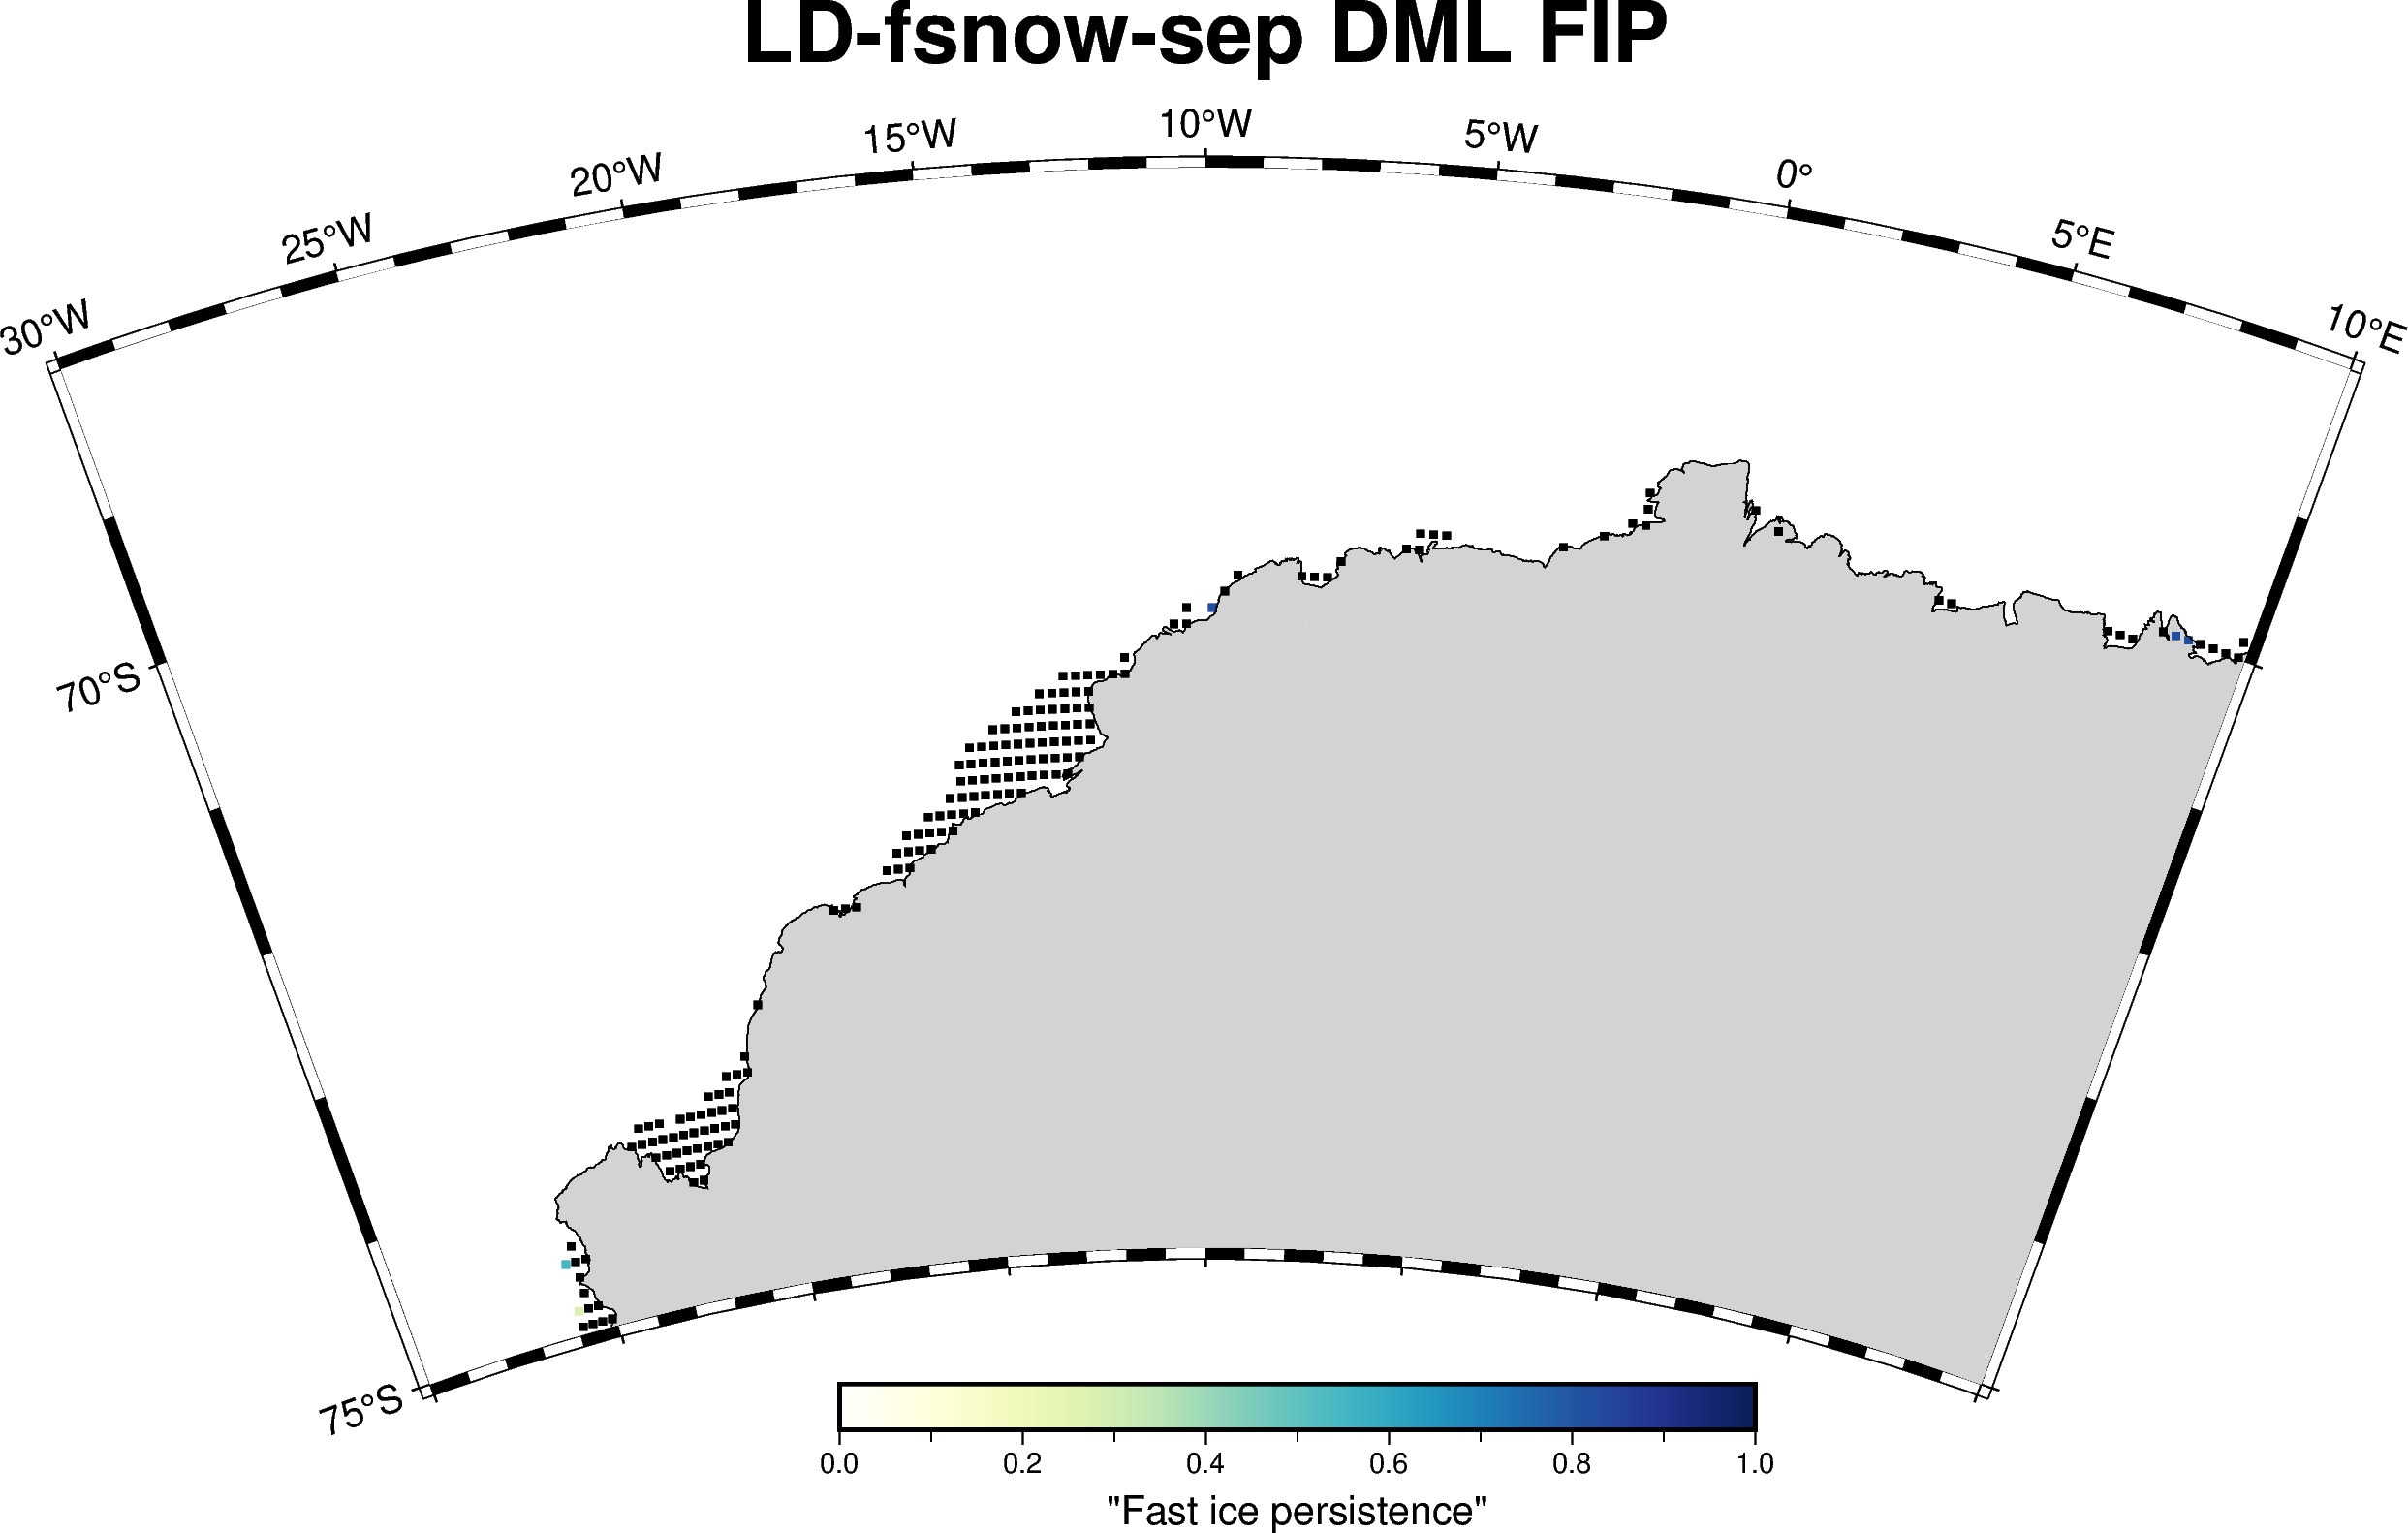

FIP: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/WIO/LD-fsnow-sep_FIP_binary-days.png


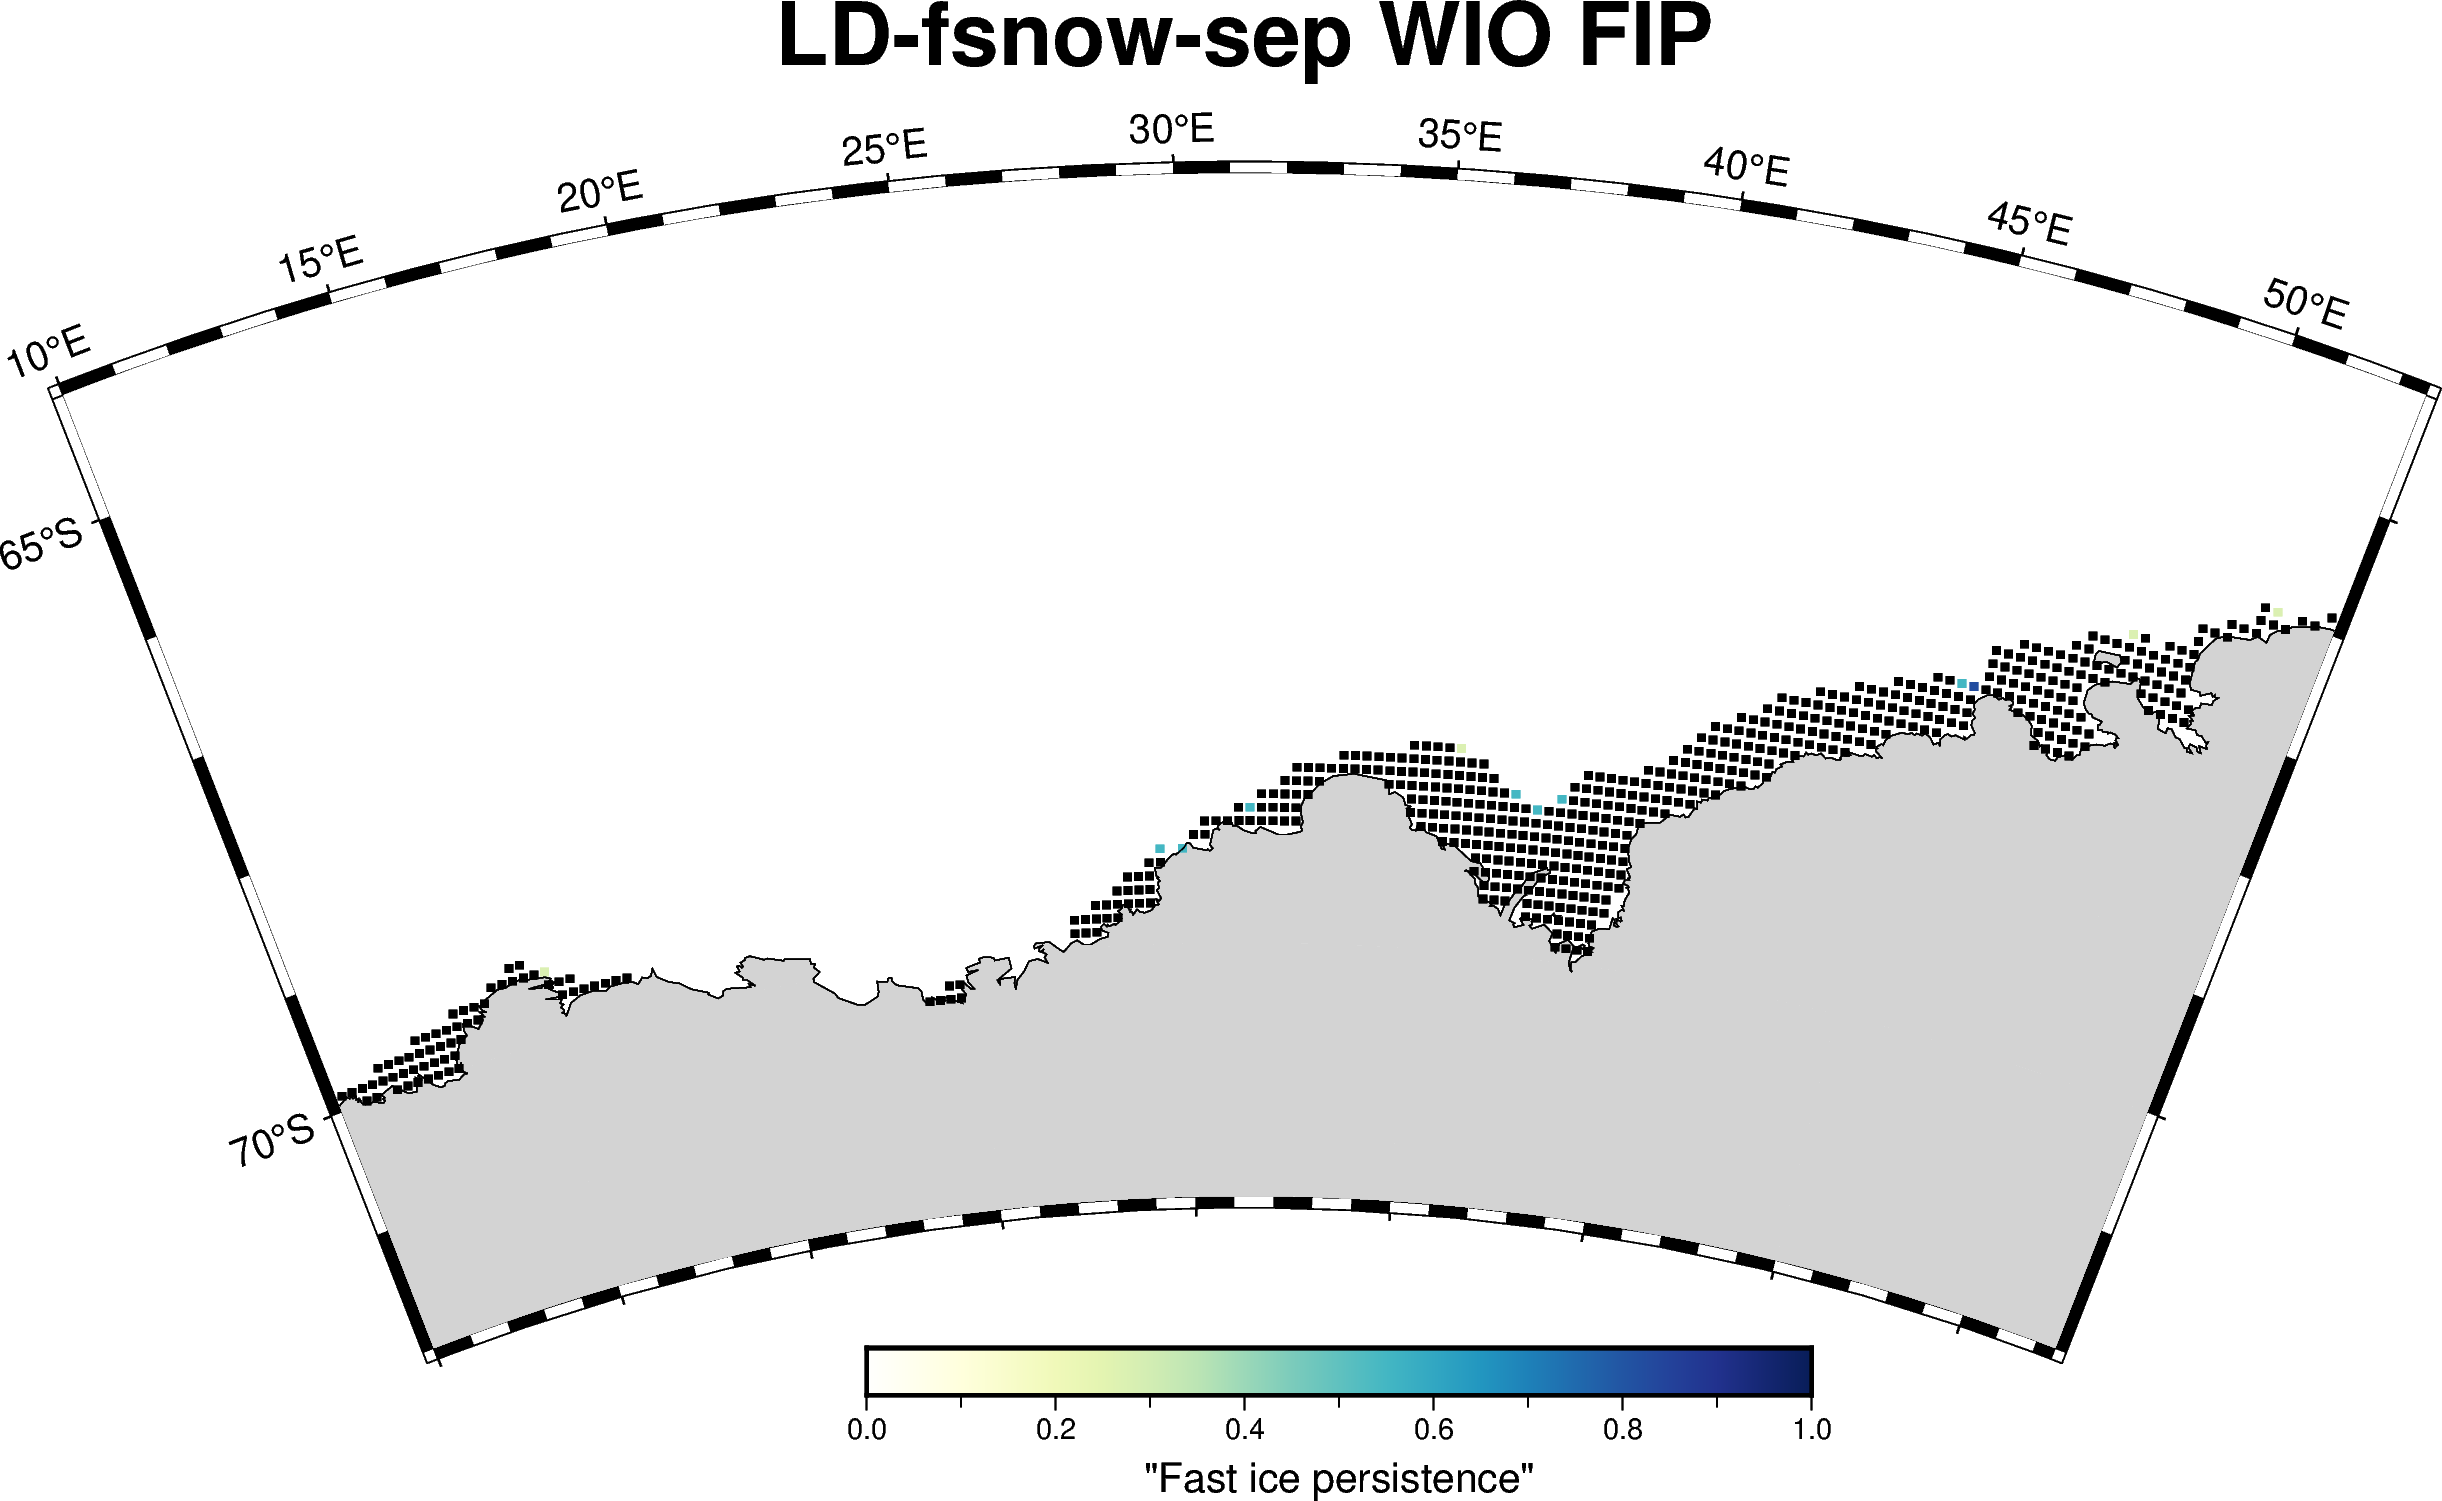

FIP: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/EIO/LD-fsnow-sep_FIP_binary-days.png


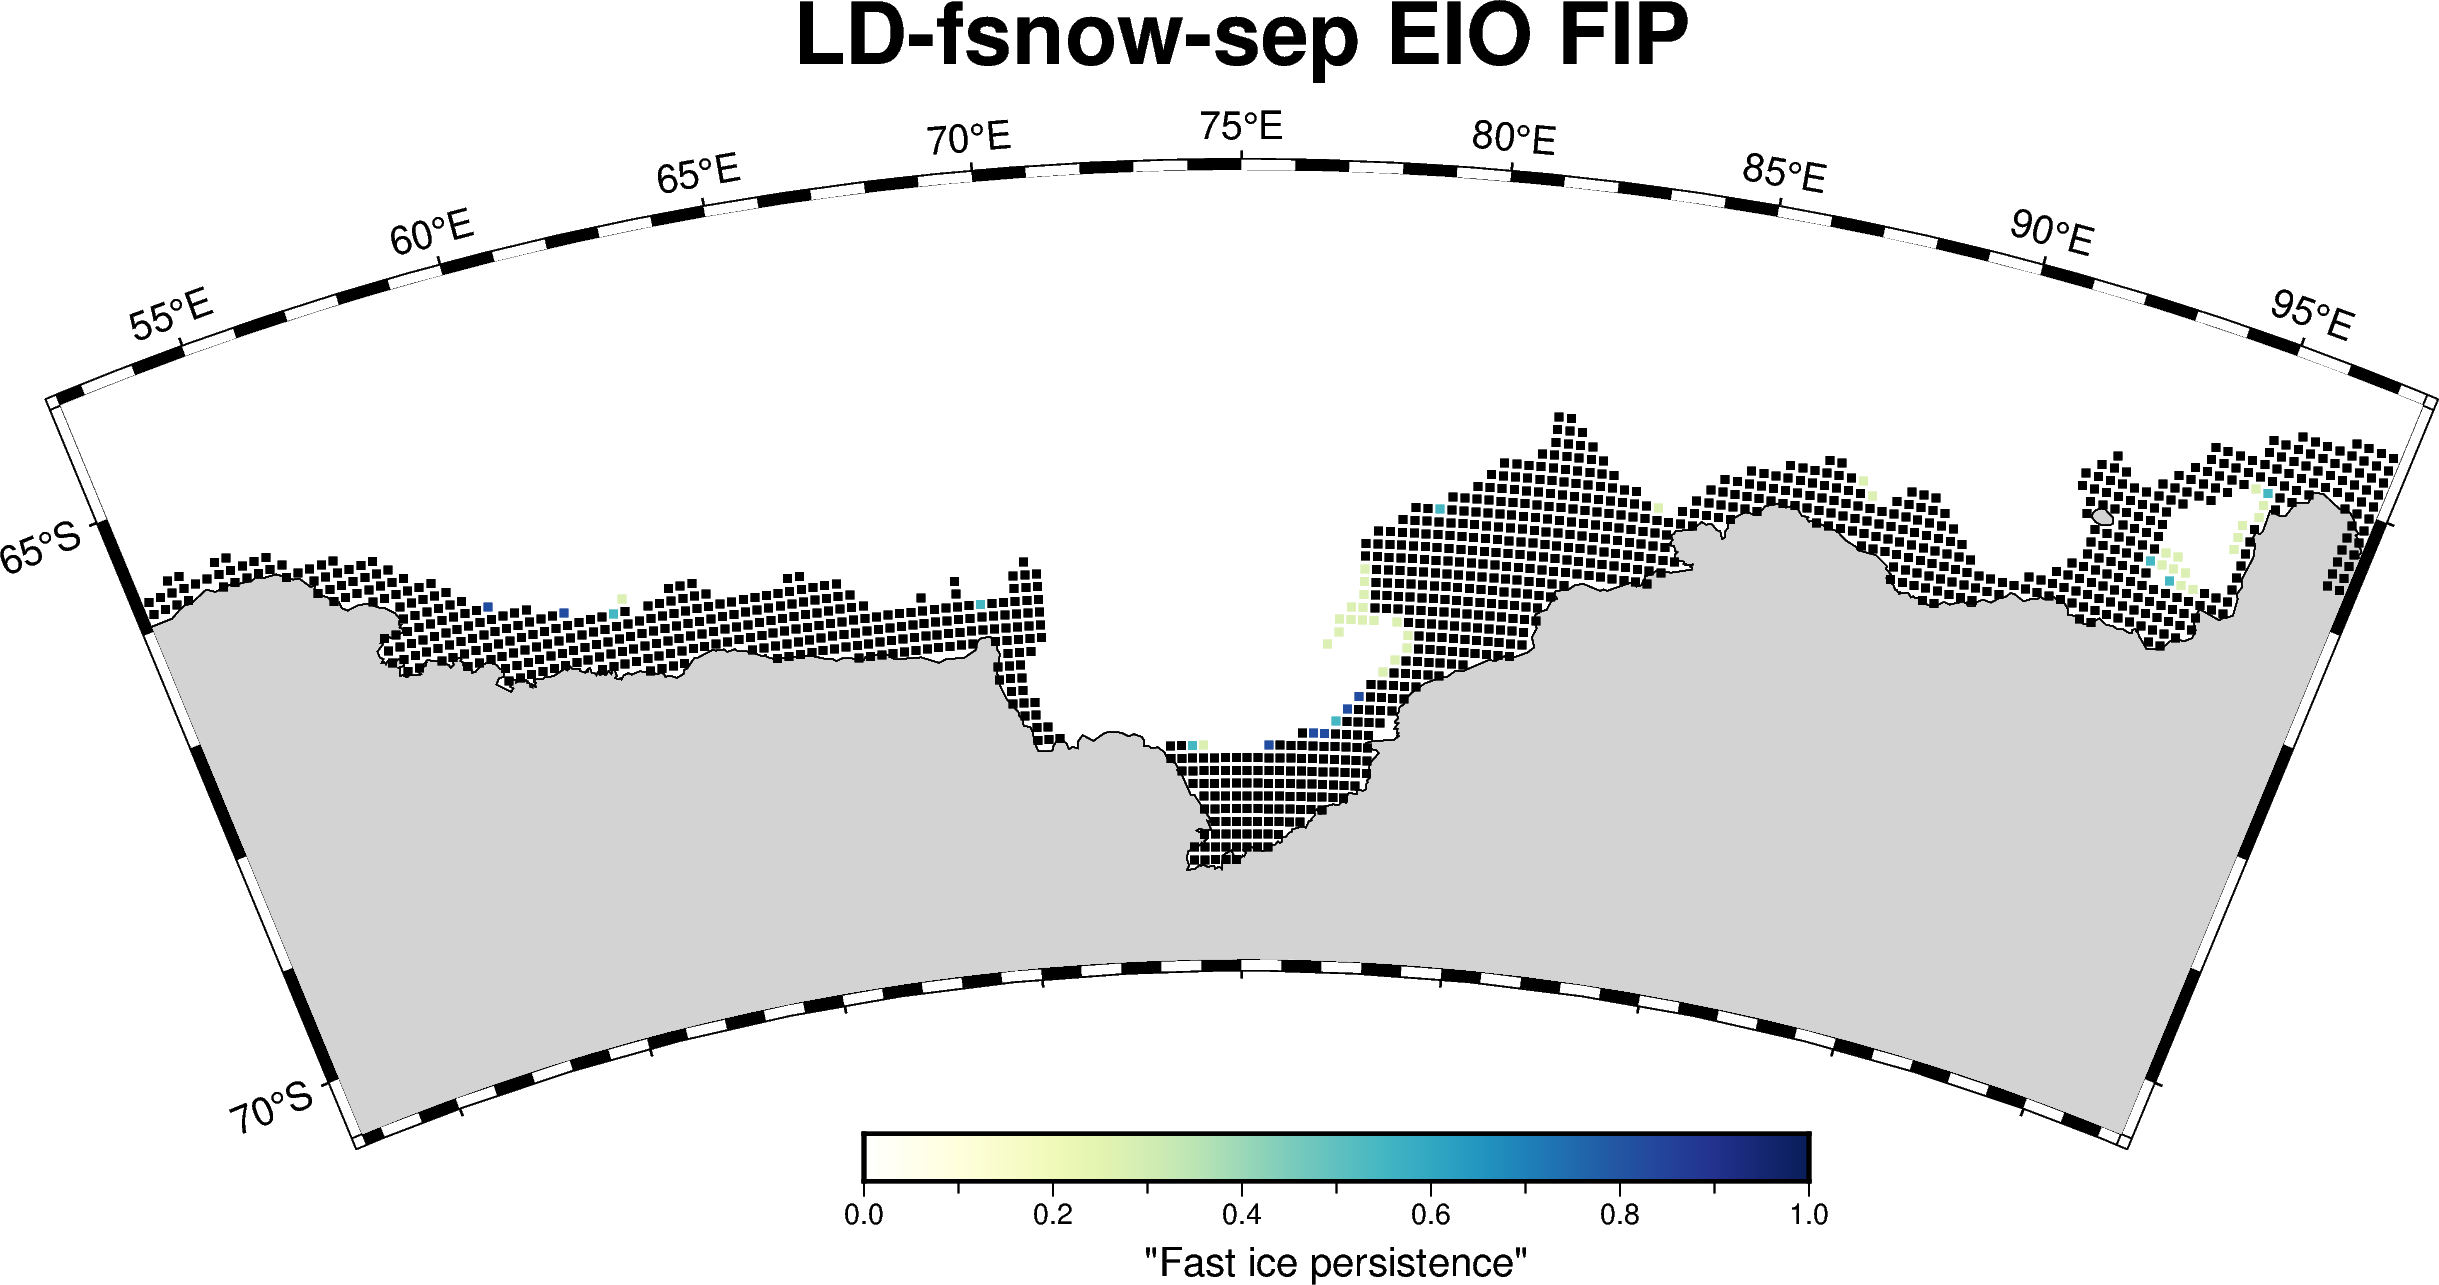

FIP: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/Aus/LD-fsnow-sep_FIP_binary-days.png


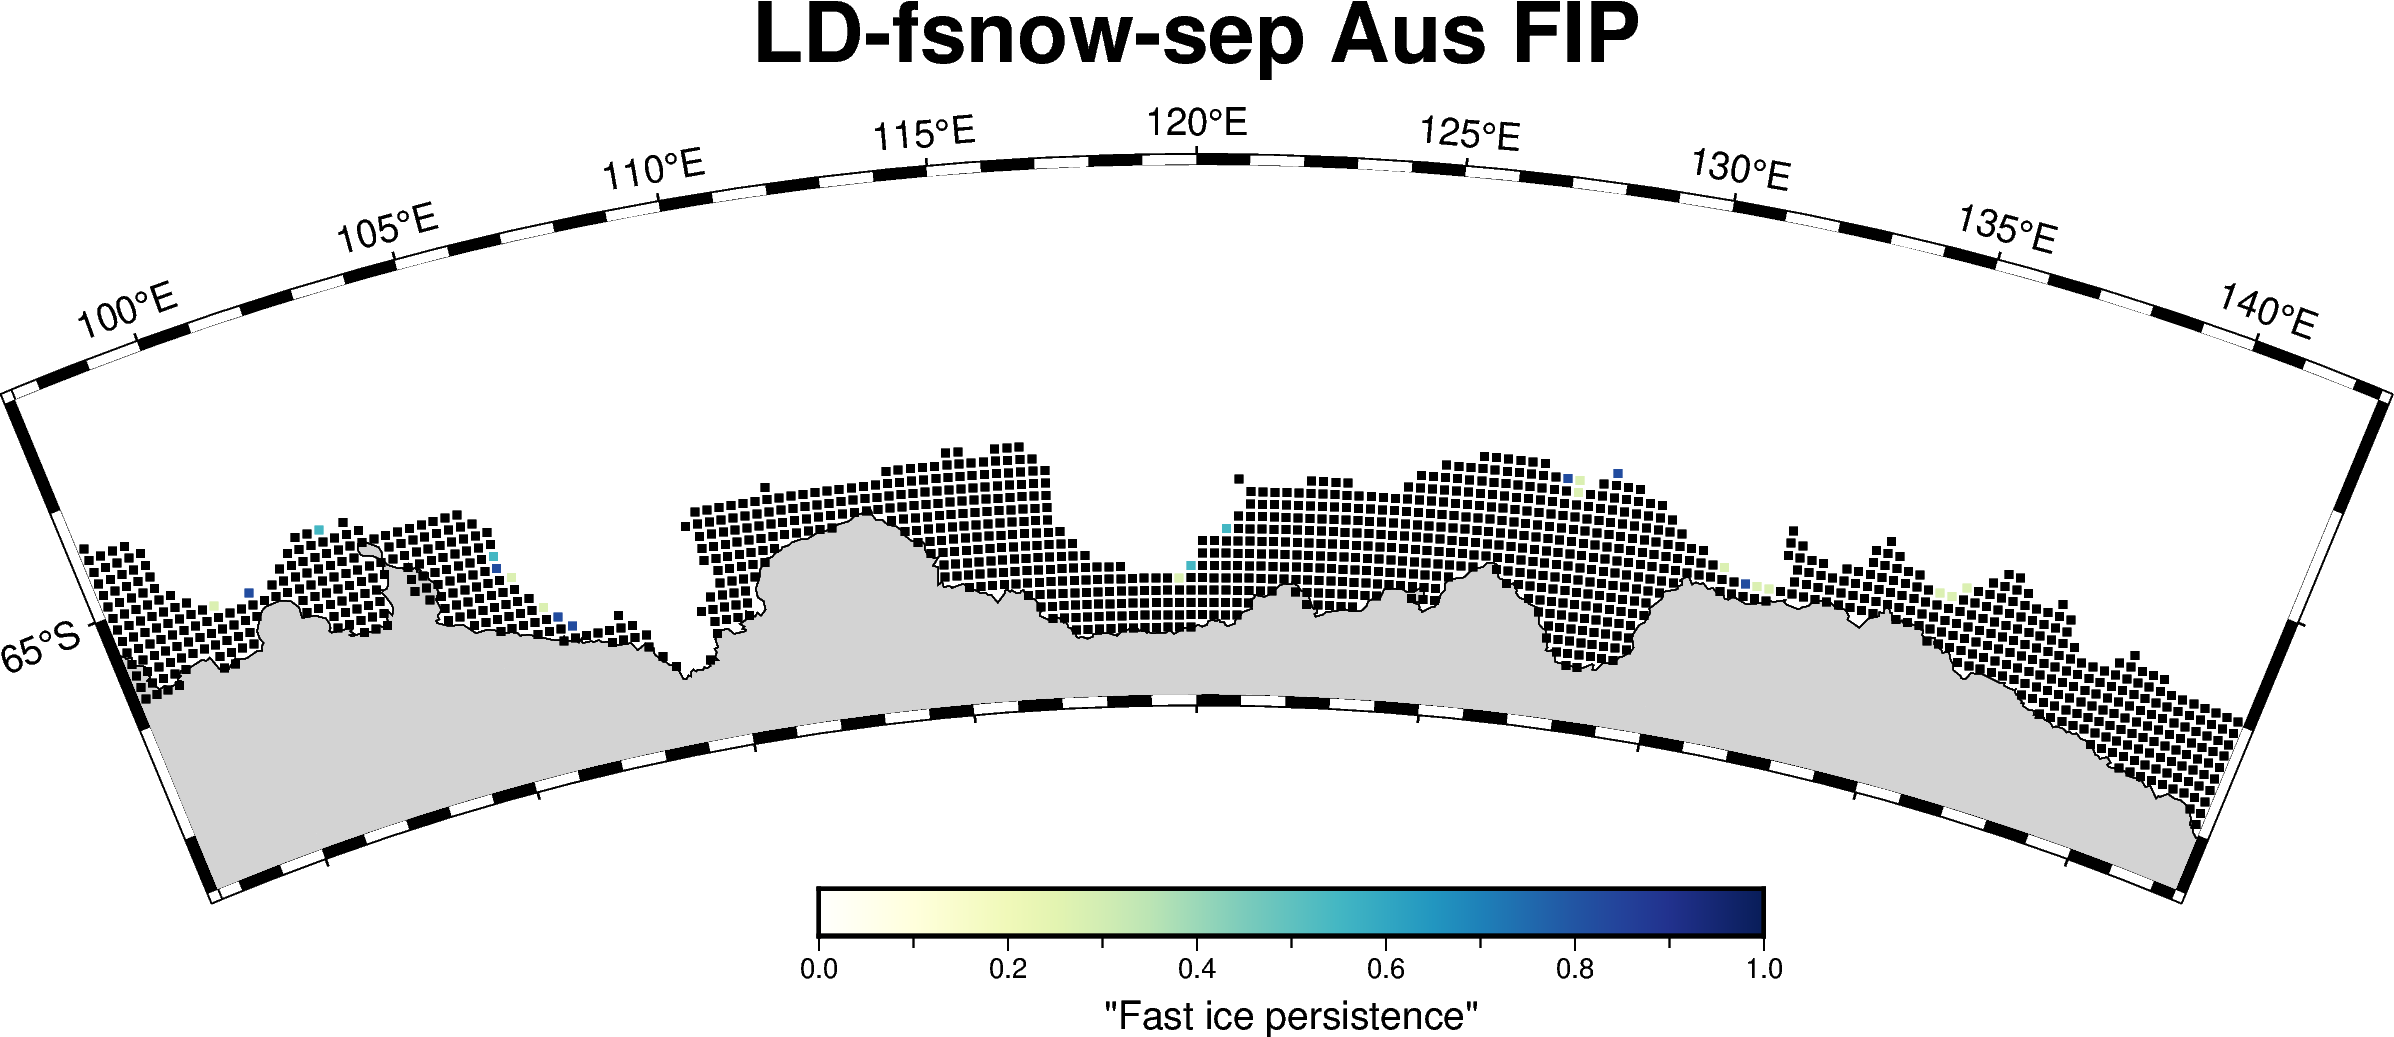

FIP: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/VOL/LD-fsnow-sep_FIP_binary-days.png


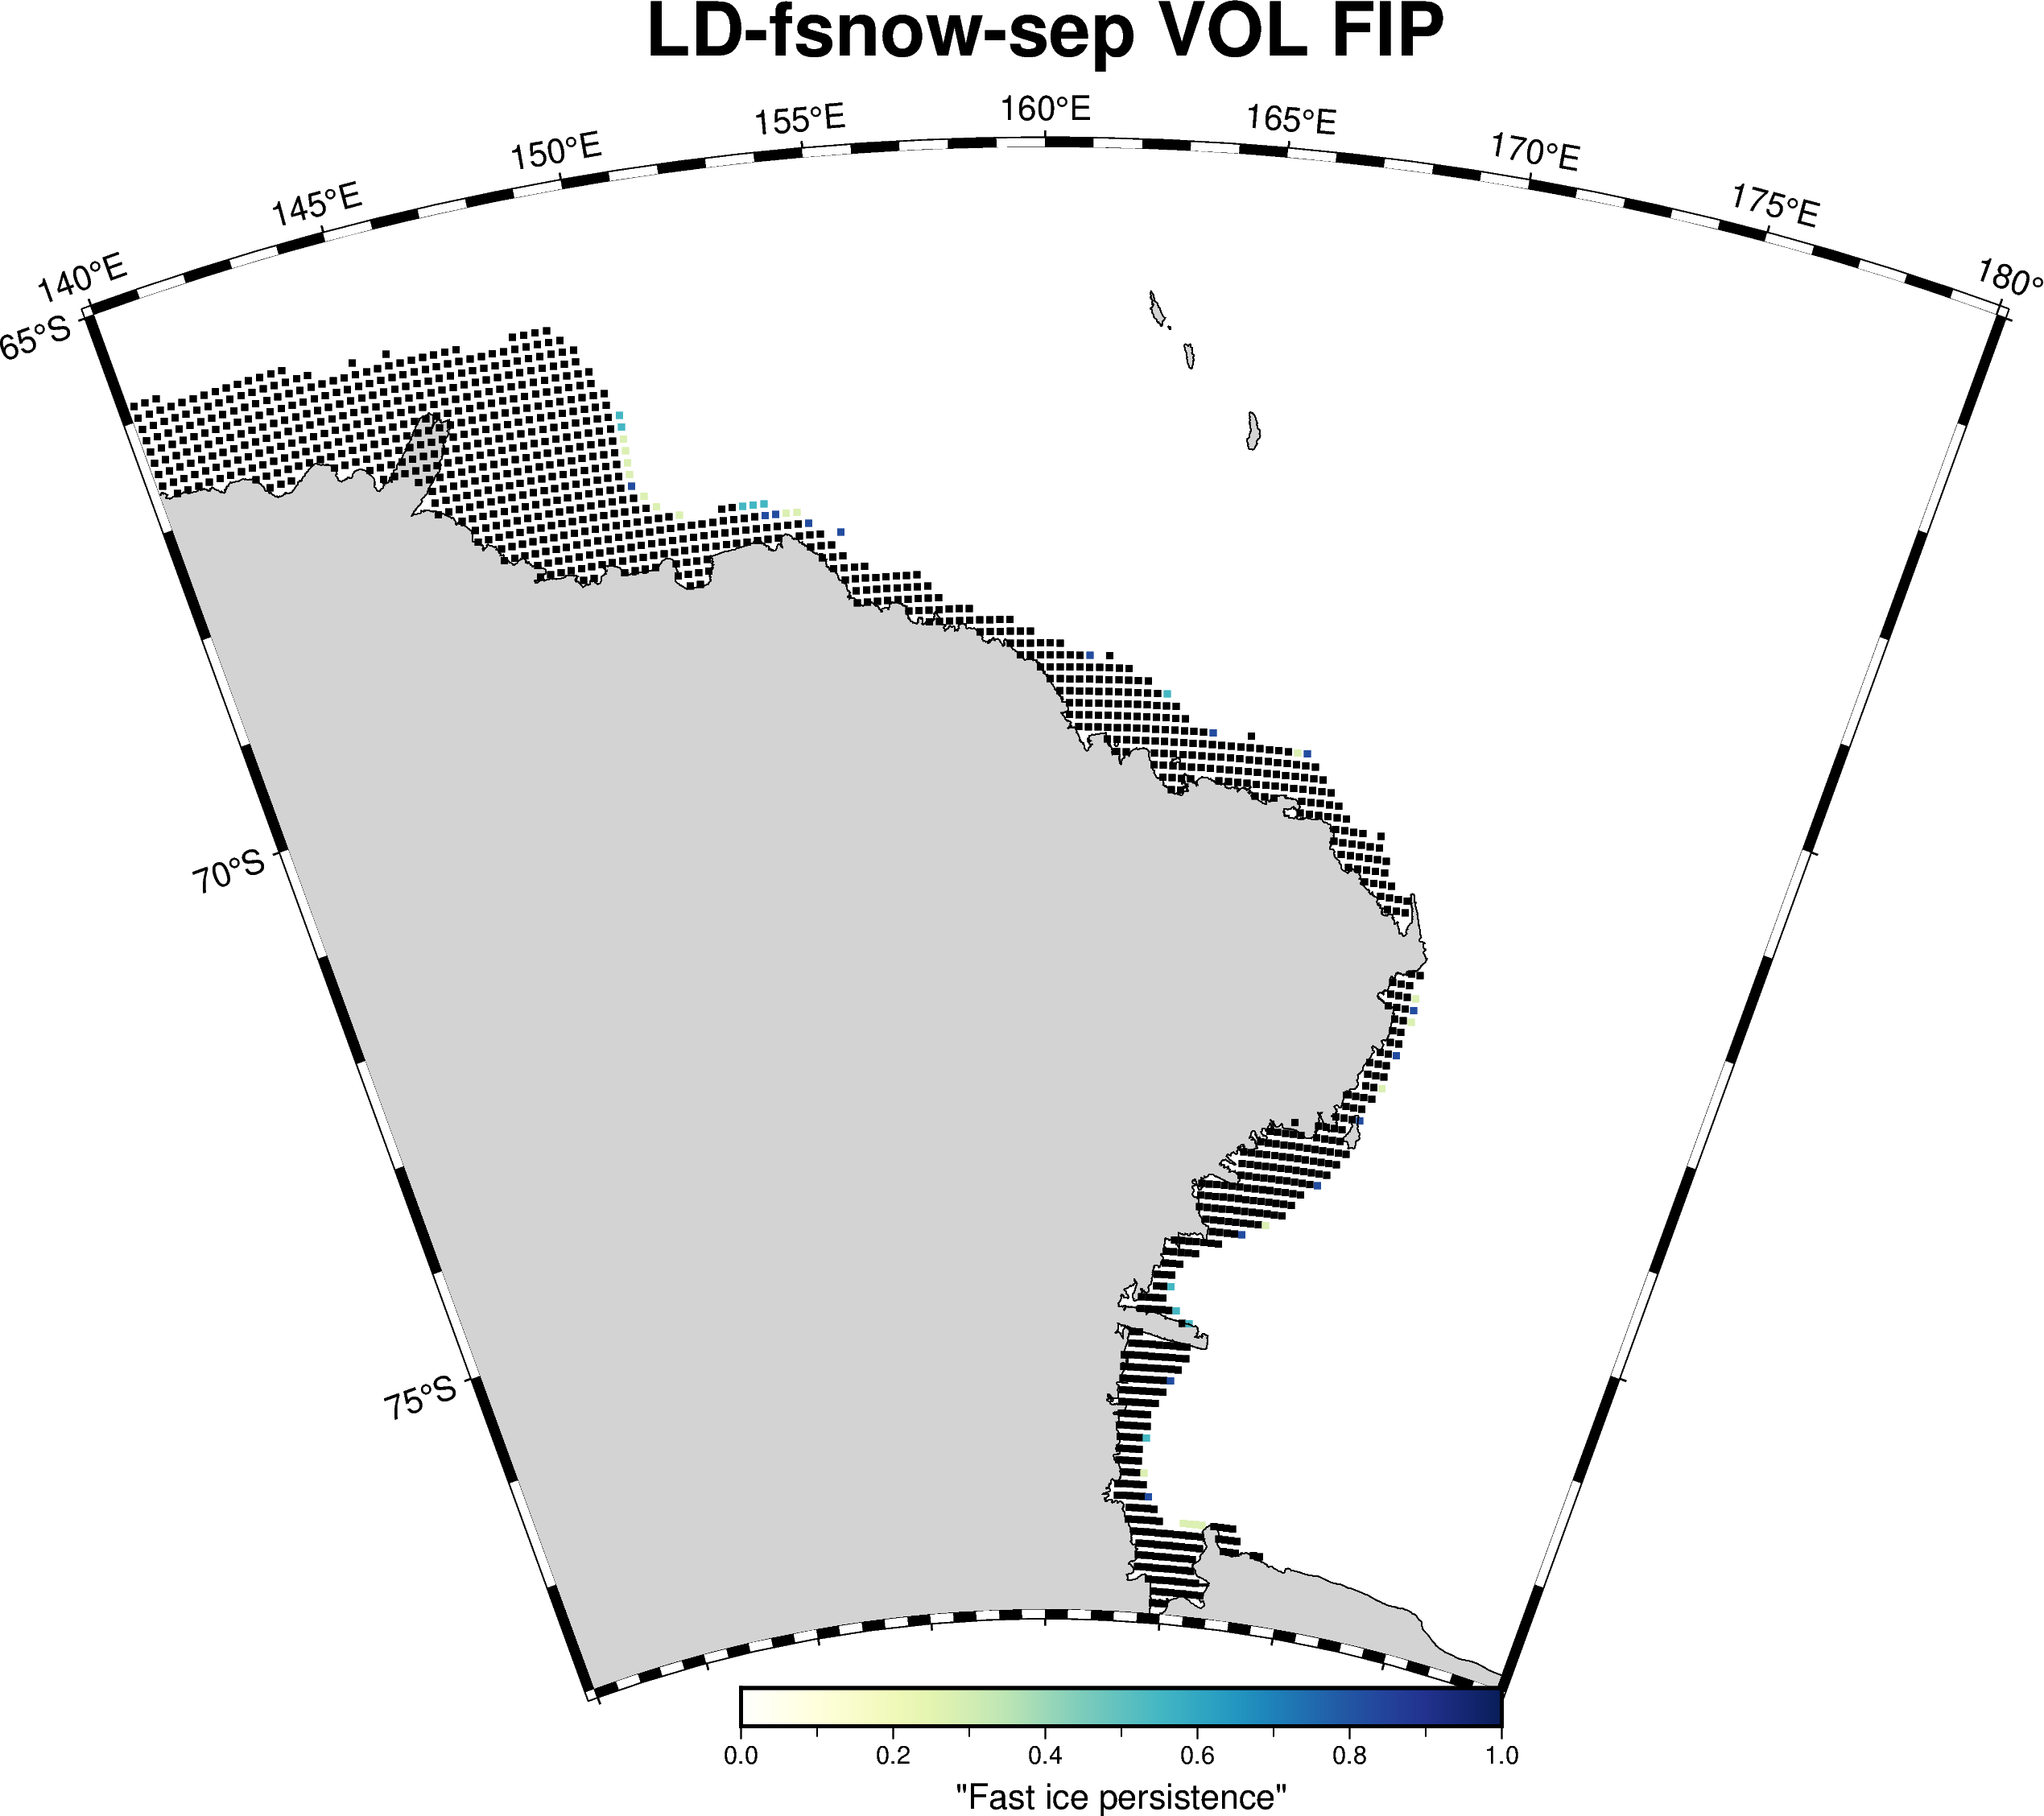

FIP: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/AS/LD-fsnow-sep_FIP_binary-days.png


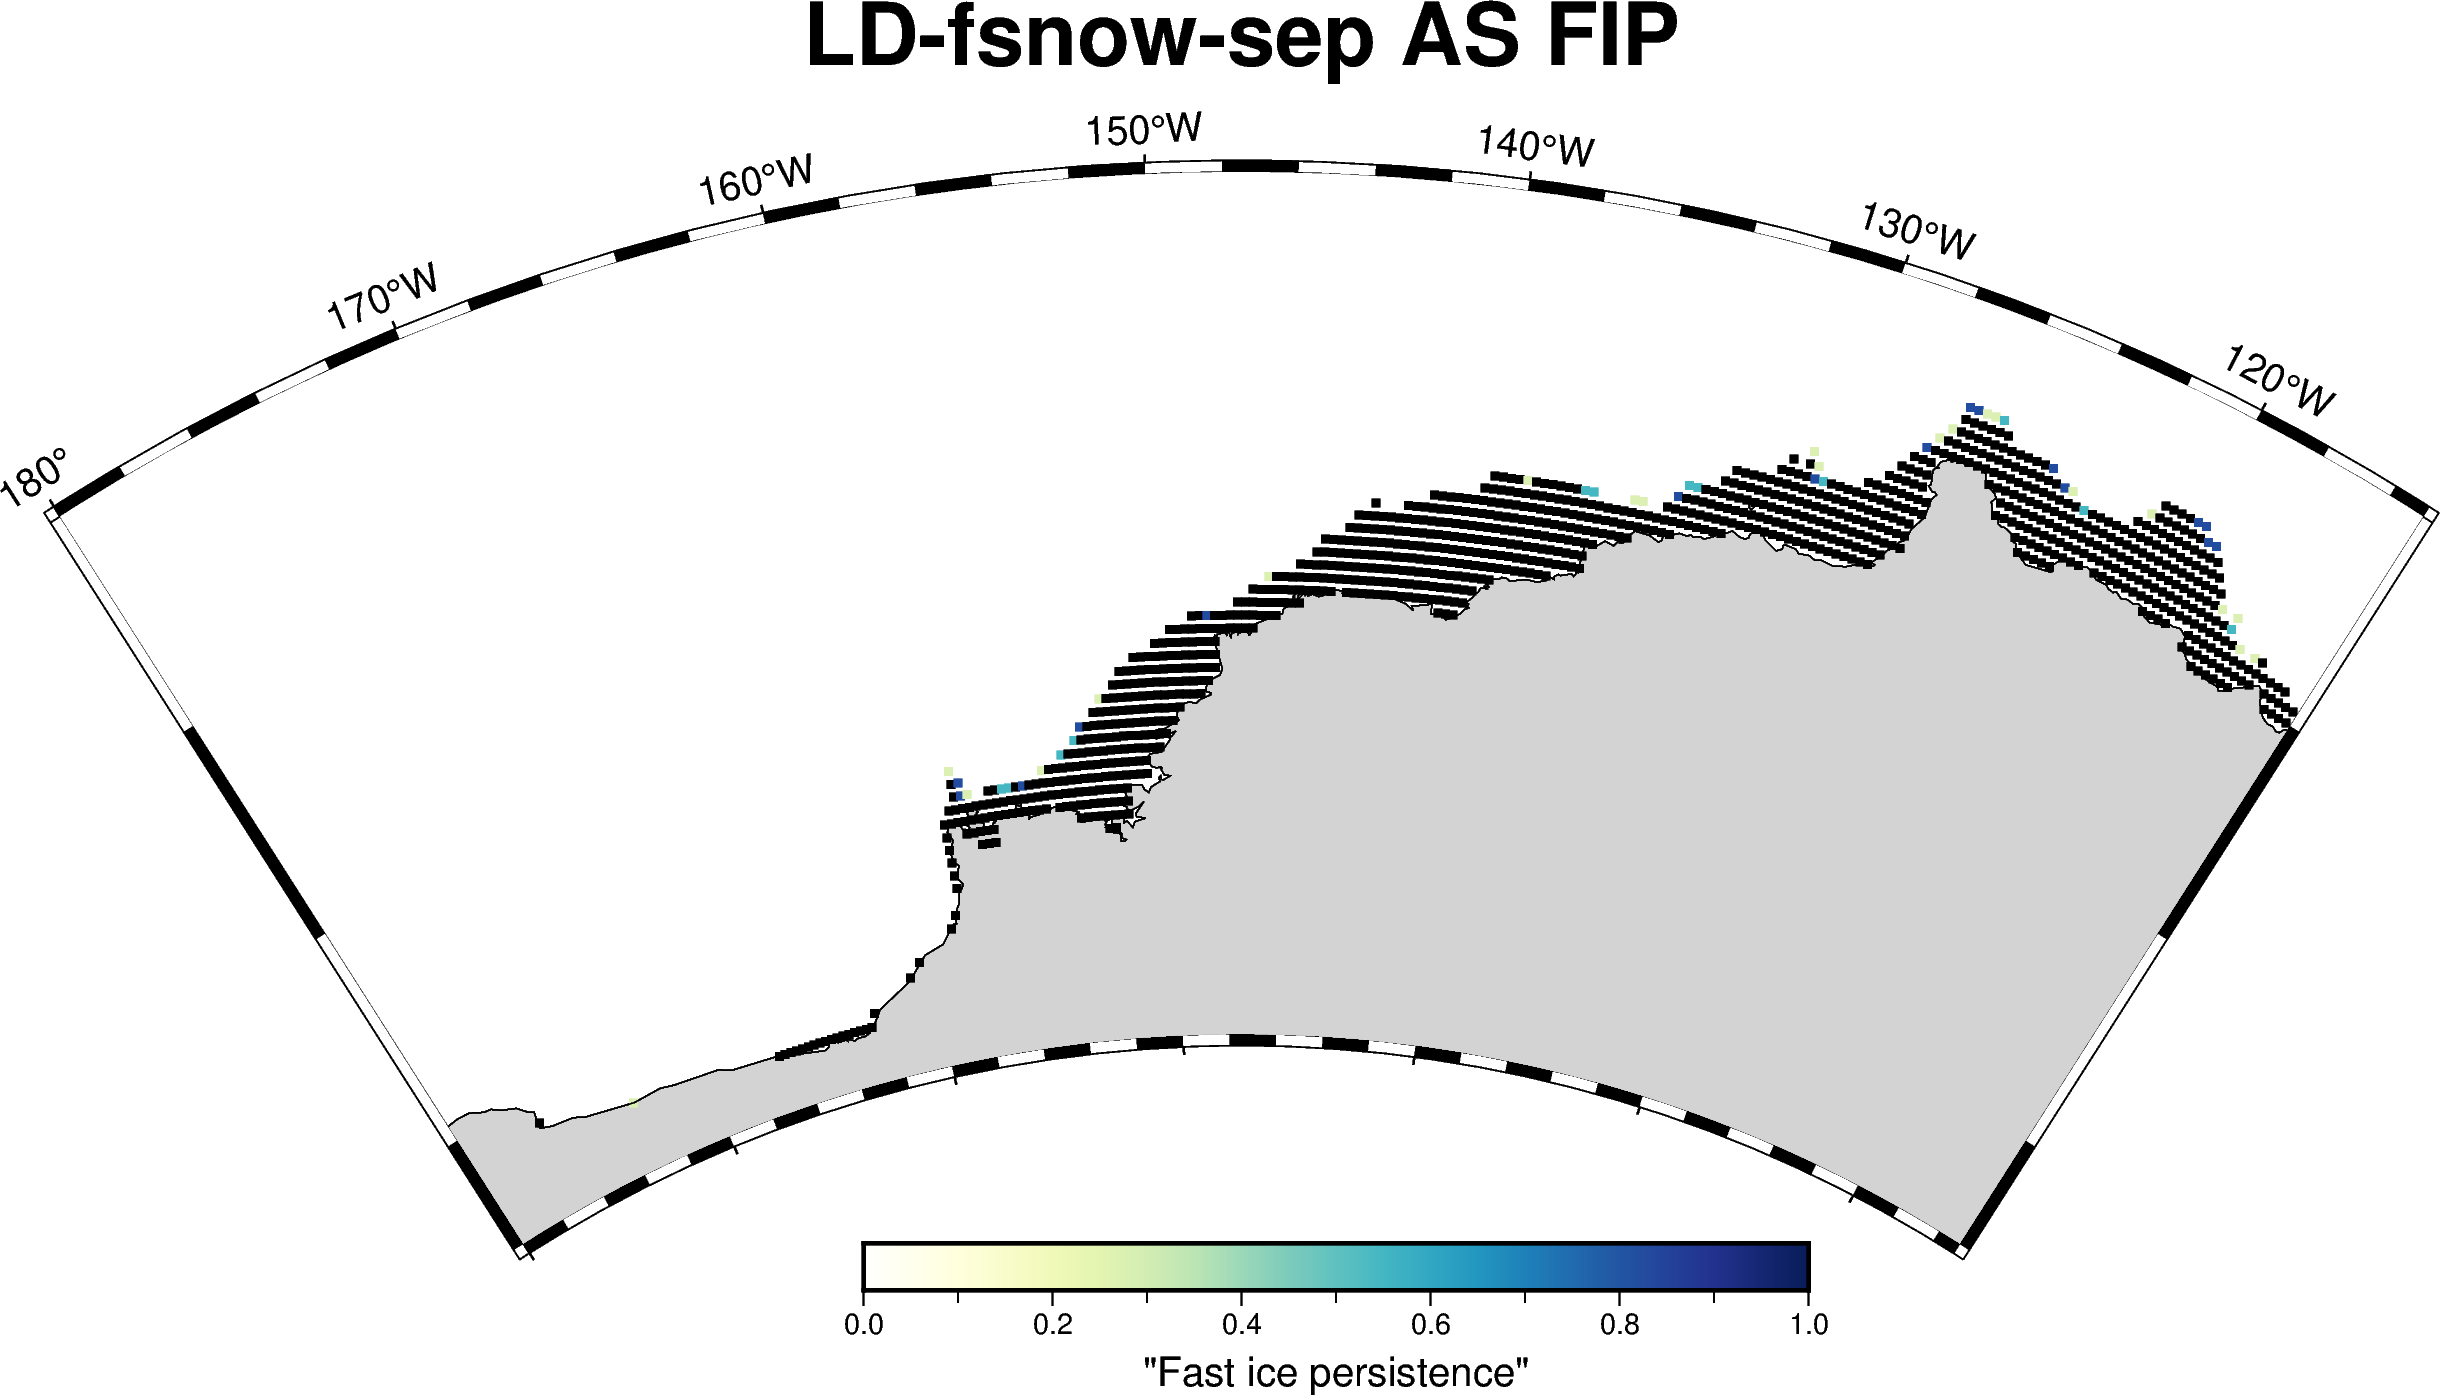

FIP: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/BS/LD-fsnow-sep_FIP_binary-days.png


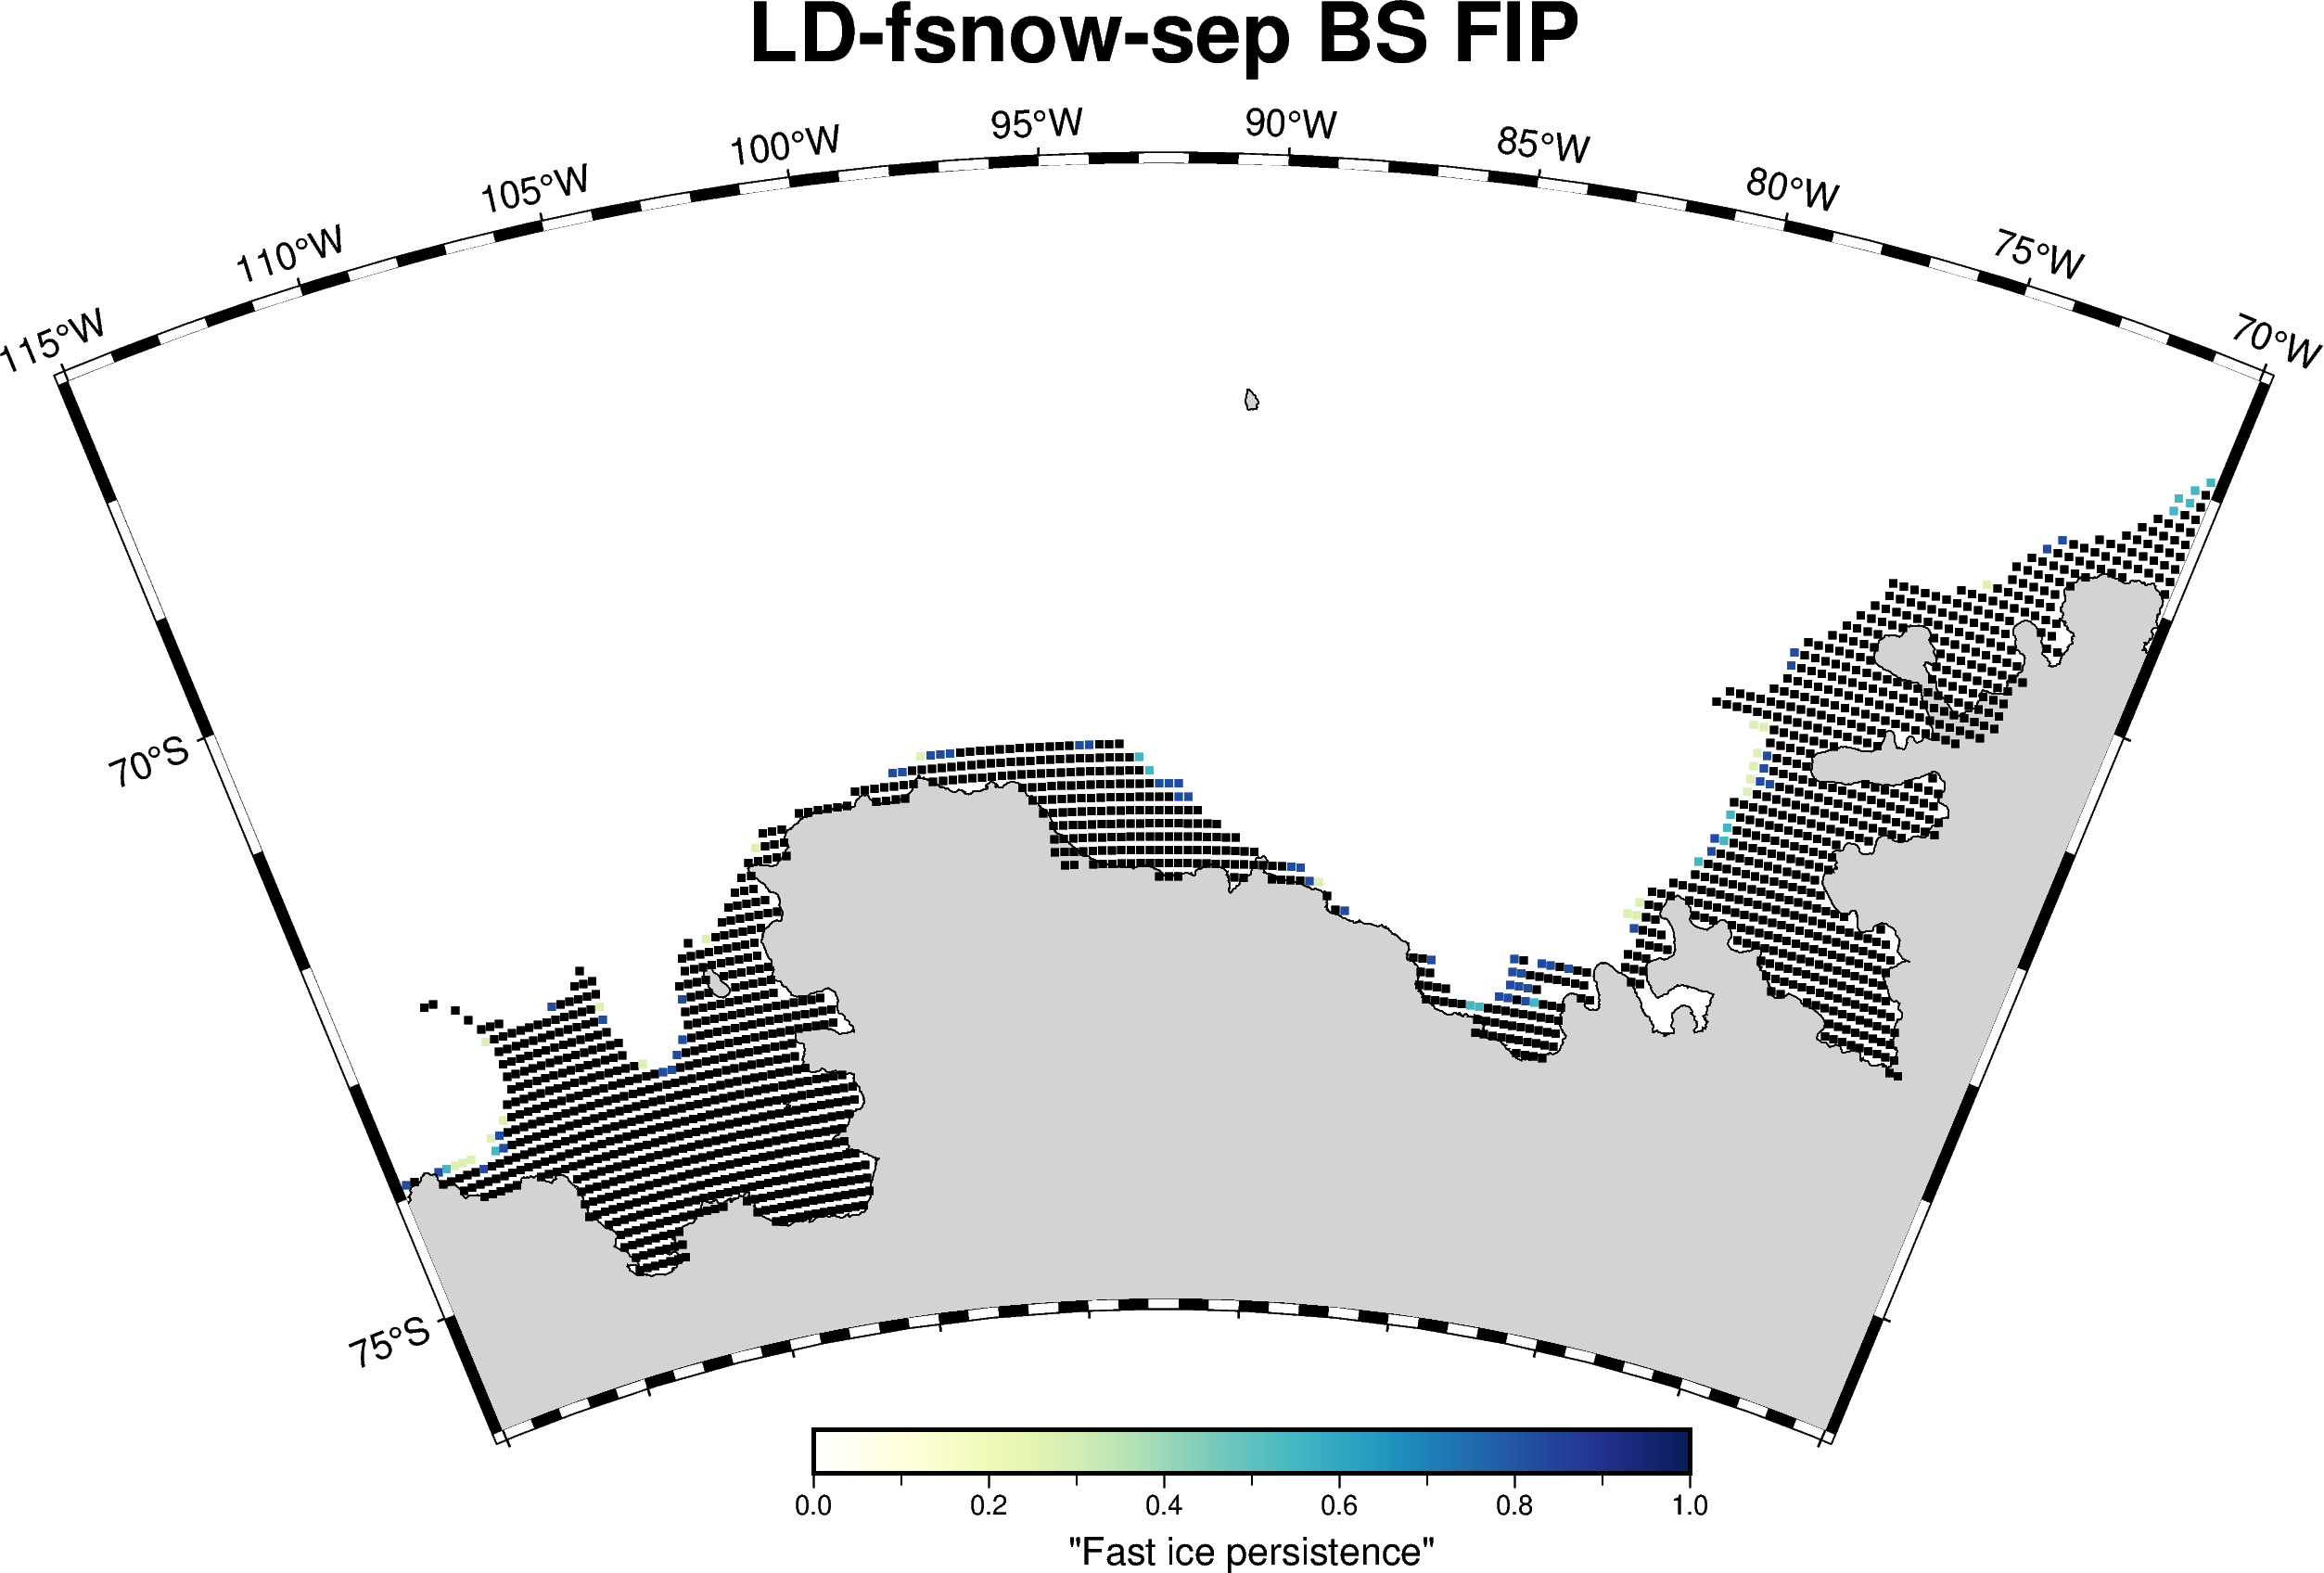

FIP: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/FIP/LD-fsnow-sep/WS/LD-fsnow-sep_FIP_binary-days.png


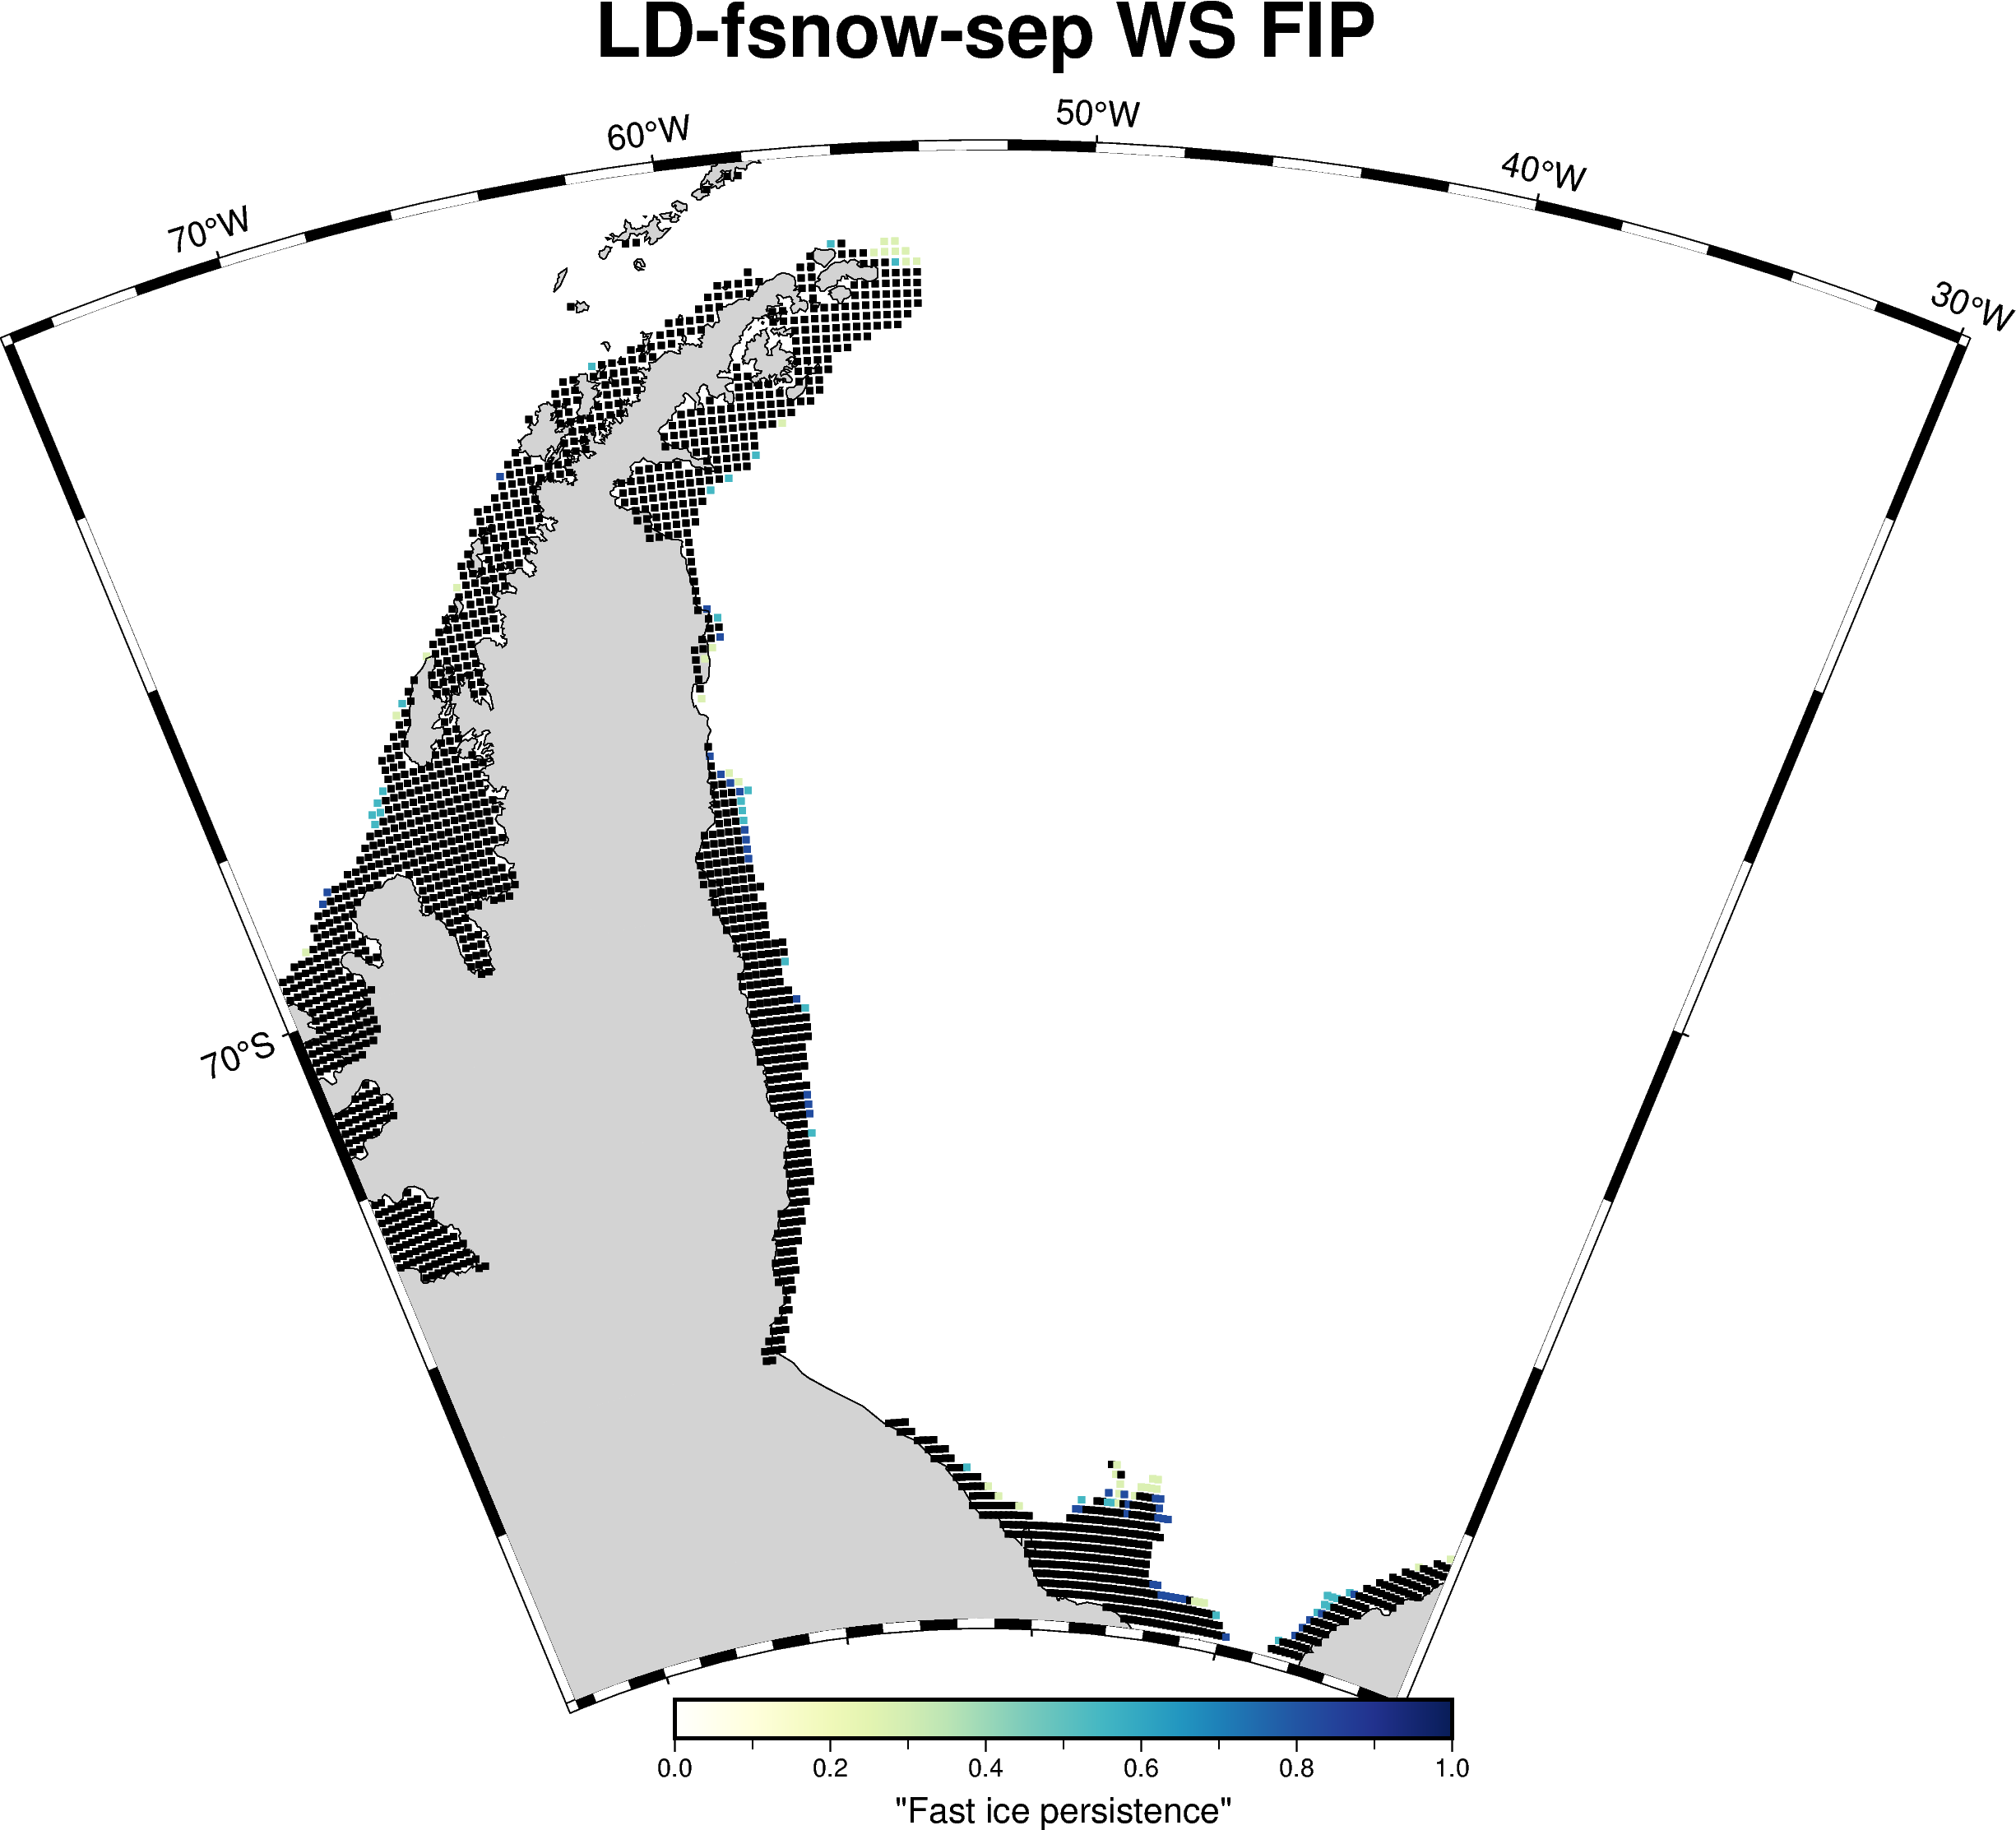

2026-06-07 14:35:10,337 - INFO - [shuga.met_cfg.plot_timeseries:750] loading metrics for LD-fsnow-sep over period 1994-01-01 -- 1994-12-31 for hemisphere SH ...
INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-fsnow-sep [Tc/binary-days] by exact path: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
INFO:shuga.io.zarr_loading:Opening metrics store for LD-fsnow-sep [Tc/binary-days]: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-06-07 14:35:10,496 - INFO - [shuga.met_cfg.plot_timeseries:792] constructing observational time-series
2026-06-07 14:35:10,909 - INFO - [shuga.met_cfg.plot_timeseries:826] creating figure
2026-06-07 14:35:10,931 - INFO - [shuga.met_cfg.plot_timeseries:842]      basemap
2026-0

[binary-days] FIA: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/total/timeseries/1994-01-01_1994-12-31_LD-fsnow-sep_FIA_binary_days.png


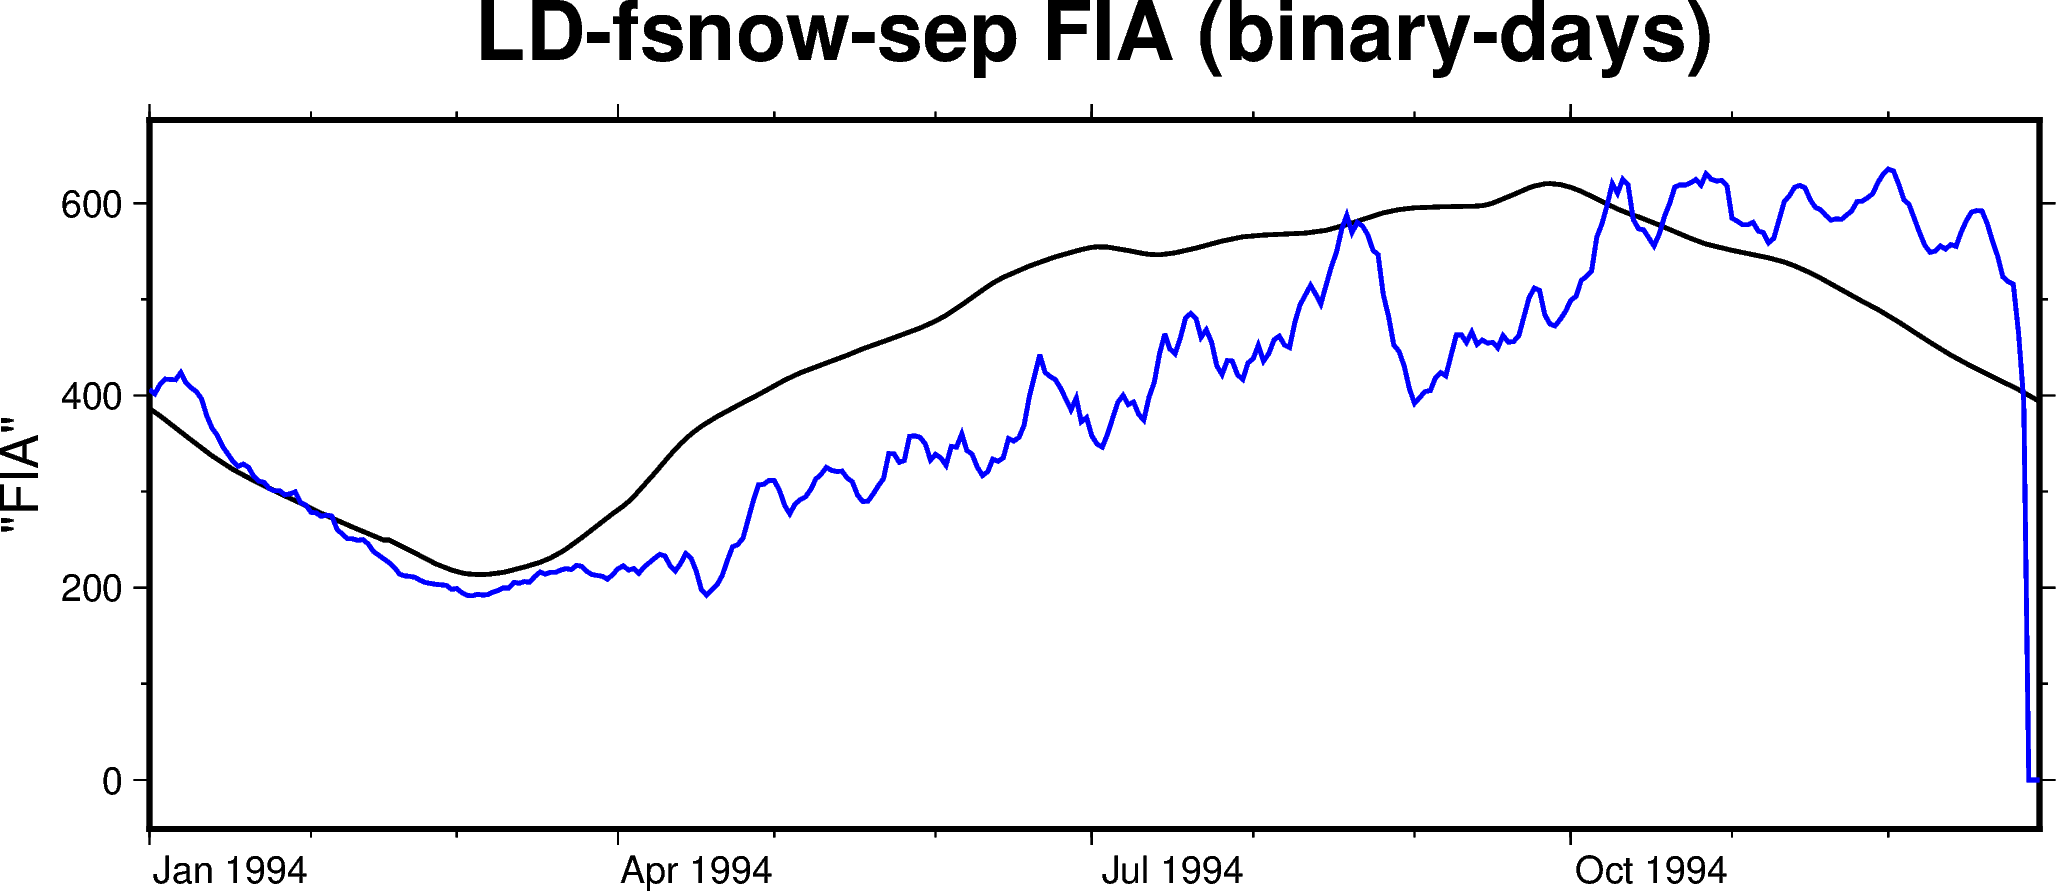

2026-06-07 14:35:11,357 - INFO - [shuga.met_cfg.plot_timeseries:750] loading metrics for LD-fsnow-sep over period 1994-01-01 -- 1994-12-31 for hemisphere SH ...
INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-fsnow-sep [Tc/binary-days] by exact path: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
INFO:shuga.io.zarr_loading:Opening metrics store for LD-fsnow-sep [Tc/binary-days]: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-06-07 14:35:11,529 - INFO - [shuga.met_cfg.plot_timeseries:792] constructing observational time-series
2026-06-07 14:35:11,530 - INFO - [shuga.met_cfg.plot_timeseries:826] creating figure
2026-06-07 14:35:11,548 - INFO - [shuga.met_cfg.plot_timeseries:842]      basemap
2026-0

[binary-days] FIT: /g/data/gv90/da1339/GRAPHICAL/LD-fsnow-sep/total/timeseries/1994-01-01_1994-12-31_LD-fsnow-sep_FIT_binary_days.png


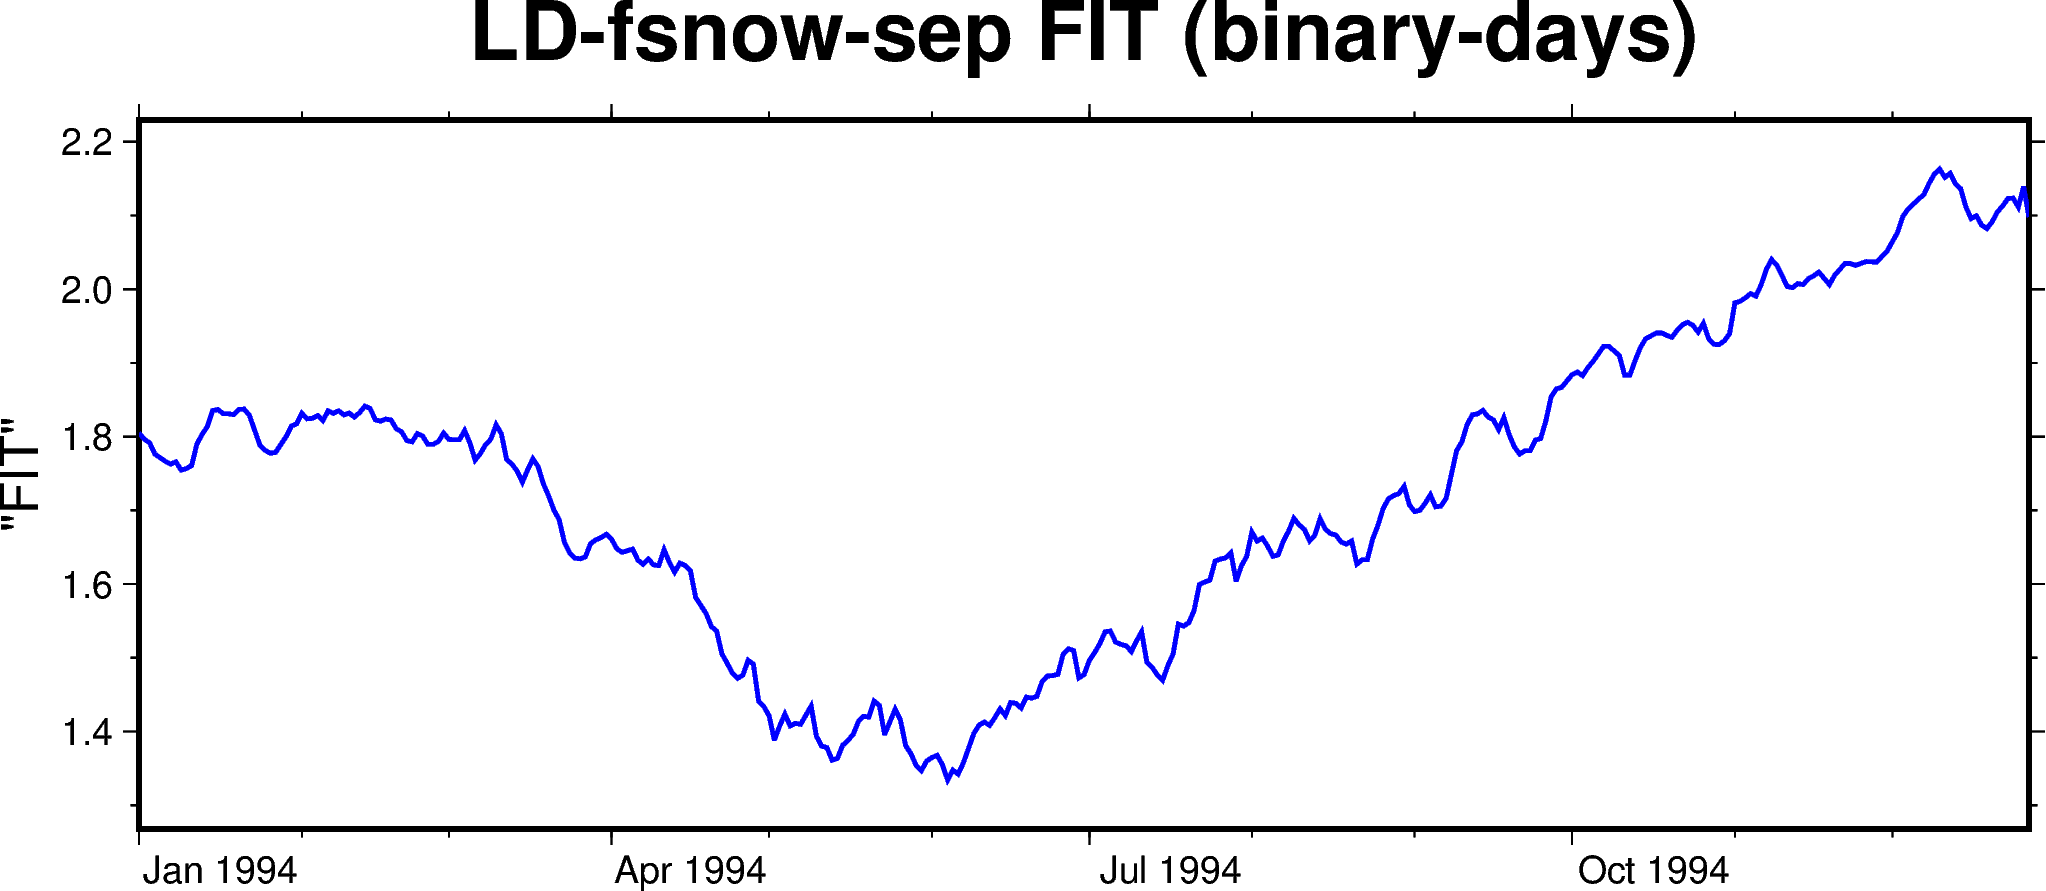

2026-06-07 14:35:11,941 - INFO - [shuga.met_cfg.plot_timeseries:750] loading metrics for LD-fsnow-sep over period 1994-01-01 -- 1994-12-31 for hemisphere SH ...
INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-fsnow-sep [Tc/binary-days] by exact path: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
INFO:shuga.io.zarr_loading:Opening metrics store for LD-fsnow-sep [Tc/binary-days]: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr


KeyError: "Variable 'SIA' not found in metrics dataset."

In [36]:
for method in methods:
    if PLOT_FIP:
        P_pngs = plotter.plot_fip(method, region_name = FIP_REGION if FIP_REGION not in {None, "", "total"} else None)
        logger.info("Wrote FIP plot(s): %s", P_pngs)
        print(f"[{method}]")
        for reg_name, P_png in P_pngs.items():
            print(f"FIP: {P_png}")
            display(Image(filename = P_png))
    if PLOT_FIA:
        P_png = plotter.plot_timeseries("FIA", method, region = PLOT_REGION)
        logger.info("Wrote FIA plot: %s", P_png)
        print(f"[{method}] FIA: {P_png}")
        display(Image(filename = P_png))
    if PLOT_FIT:
        P_png = plotter.plot_timeseries("FIT", method, region = PLOT_REGION, add_f2020 = False)
        logger.info("Wrote FIT plot: %s", P_png)
        print(f"[{method}] FIT: {P_png}")
        display(Image(filename = P_png))
    if PLOT_SIA:
        P_png = plotter.plot_timeseries("SIA", method, region = PLOT_REGION, add_f2020 = False)
        logger.info("Wrote SIA plot: %s", P_png)
        print(f"[{method}] SIA: {P_png}")
        display(Image(filename = P_png))
    if PLOT_SIT:
        P_png = plotter.plot_timeseries("SIT", method, region = PLOT_REGION, add_f2020 = False)
        logger.info("Wrote SIT plot: %s", P_png)
        print(f"[{method}] SIT: {P_png}")
        display(Image(filename = P_png))

## Inspect the metrics stores


In [ ]:
from shuga import load_metrics

for method in methods:
    try:
        ds = load_metrics(run_cfg        = run_cfg,
                          cls_cfg        = cls_cfg,
                          met_cfg        = met_cfg,
                          pth_cfg        = pth_cfg,
                          classification = method,
                          variables      = None)
        print(f"\n[{method}]")
        print(ds)
    except Exception as exc:
        print(f"Could not open metrics output for {method}: {exc}")
